# All Proposed Methods vs Baselines on the Bank Telemarketing Upsell dataset


In [18]:
# =============================================================================
# IMPORTS & CONFIGURATION
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats as scipy_stats

import sklearn
sklearn.set_config(enable_metadata_routing=True)

from sklearn.calibration import calibration_curve
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier
from empulse.datasets import (
    load_churn_tv_subscriptions,
    load_credit_scoring_pakdd,
    load_give_me_some_credit,
    load_upsell_bank_telemarketing,
)
from scipy.special import expit

from empulse.metrics import expected_cost_loss
from empulse.metrics.metric.prebuilt_metrics import make_generic_cost_metric
from empulse.metrics._loss import cy_boost_grad_hess
from empulse.models import CSLogitClassifier, CSBoostClassifier
from hybrid_aug_mlp import fit_hybrid_mlp, predict_proba_hybrid_mlp
from transfer_nn import train_transfer_nn, predict_proba_transfer_nn

RANDOM_STATE = 42
N_OUTER_FOLDS = 5
N_REPETITIONS = 2
N_INNER_FOLDS = 3
N_JOBS = 1

BASELINE_LOGIT_GRID = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.0, 0.5, 1.0],
}
BASELINE_CSLOGIT_GRID = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.0, 0.5, 1.0],
}
BASELINE_BOOST_GRID = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__min_child_weight': [1, 3, 5],
}
BASELINE_CSBOOST_GRID = {
    'model__estimator__n_estimators': [100, 200],
    'model__estimator__learning_rate': [0.05, 0.1],
    'model__estimator__max_depth': [2, 3],
    'model__estimator__min_child_weight': [1, 3, 5],
}

LAYER_HEAD_PARAM_GRID = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [1.0],
}

WEIGHTED_ALPHA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
WEIGHTED_XGB_PARAM_GRID = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
}

COSTLOSS_GAMMA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
COSTLOSS_BETA_GRID = [1.0, 1.5, 2.0, 3.0, 5.0]
COSTLOSS_XGB_PARAM_GRID = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
}

TRANSFER_N_PRETRAIN_GRID = [50, 100, 200]
TRANSFER_N_FINETUNE_GRID = [50, 100, 150]
TRANSFER_GAMMA_GRID = [0.25, 0.5, 0.75, 1.0]
TRANSFER_XGB_PARAM_GRID = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
}

TRANSFER_NN_PRETRAIN_EPOCHS_GRID = [50, 100, 200]
TRANSFER_NN_FINETUNE_EPOCHS_GRID = [50, 100, 150]
TRANSFER_NN_GAMMA_GRID = [0.25, 0.5, 0.75, 1.0]
TRANSFER_NN_PARAM_GRID = {
    'hidden_dim': [32, 64],
    'lr': [1e-3, 3e-3],
}
TRANSFER_NN_FREEZE_BACKBONE = True

TEACHER_CSBOOST_GRID = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
}

# Teacher-augmented hybrid XGB: lambda * AEC_boost + (1-lambda) * log loss (see hybrid_cost_logloss_eval.ipynb)
# Inner CV jointly selects lambda from this grid with HYBRID_AUG_XGB_GRID (min mean inner AEC).
HYBRID_LAMBDA_GRID = [0.3, 0.5, 0.7, 0.9]
HYBRID_XGB_EXTRA = {'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}
HYBRID_AUG_XGB_GRID = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2],
}

# Hybrid MLP: λ·mean(expected cost) + (1−λ)·BCE on logits (hybrid_aug_mlp.py); same λ grid search as hybrid_aug_xgb
HYBRID_AUG_MLP_GRID = {
    'hidden_dim': [32, 64],
    'lr': [1e-3, 3e-3],
    'n_epochs': [80],
}


In [19]:
# =============================================================================
# LOAD DATA
# =============================================================================
dataset = load_upsell_bank_telemarketing(as_frame=True)

X = dataset.data.copy()
y = dataset.target.copy()

tp_cost = dataset.tp_cost
fp_cost = dataset.fp_cost
tn_cost = dataset.tn_cost
fn_cost = dataset.fn_cost

print('Dataset: Bank telemarketing upsell')
print(f'Samples: {len(y):,}')
print(f'Features: {X.shape[1]}')
print(f'Positive rate: {np.mean(y):.2%}')
if hasattr(X, 'isna'):
    missing_by_col = X.isna().sum()
    missing_by_col = missing_by_col[missing_by_col > 0]
    print(f'Total missing values: {int(X.isna().sum().sum())}')
    if len(missing_by_col):
        print('Columns with missing values:')
        print(missing_by_col.sort_values(ascending=False))


Dataset: Bank telemarketing upsell
Samples: 37,931
Features: 10
Positive rate: 12.62%
Total missing values: 0


Instance-dependent cost structure:


,scalar,value,mean,std,min,q25,median,q75,max
name,,,,,,,,,
tp_cost,True,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fp_cost,True,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tn_cost,True,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fn_cost,False,NaN,10.3059,19.8994,1.0,1.3949,3.966,10.9372,628.932



FN/FP cost ratio — mean: 10.31, median: 3.97, min: 1.00, max: 628.93


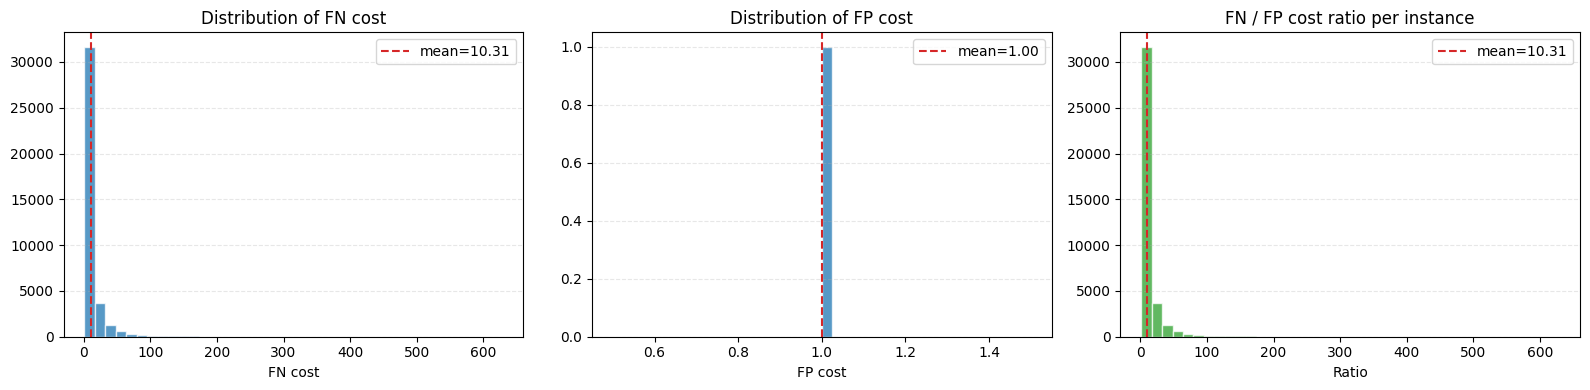

In [20]:
# =============================================================================
# COST STRUCTURE SUMMARY
# =============================================================================
def _cost_summary_series(name, values):
    a = np.asarray(values, dtype=float).ravel()
    if a.ndim == 0 or a.size == 1:
        return pd.Series({'name': name, 'scalar': True, 'value': float(a.flat[0])})
    return pd.Series({
        'name': name, 'scalar': False,
        'mean': float(a.mean()), 'std': float(a.std()),
        'min': float(a.min()), 'q25': float(np.percentile(a, 25)),
        'median': float(np.median(a)), 'q75': float(np.percentile(a, 75)),
        'max': float(a.max()),
    })

cost_info = pd.DataFrame([
    _cost_summary_series('tp_cost', tp_cost),
    _cost_summary_series('fp_cost', fp_cost),
    _cost_summary_series('tn_cost', tn_cost),
    _cost_summary_series('fn_cost', fn_cost),
]).set_index('name')

print('Instance-dependent cost structure:')
display(cost_info.round(4))

fn_arr_tmp = np.asarray(fn_cost, dtype=float).ravel()
fp_arr_tmp = np.asarray(fp_cost, dtype=float).ravel()
if fn_arr_tmp.size > 1 or fp_arr_tmp.size > 1:
    ratio = fn_arr_tmp / (fp_arr_tmp + 1e-12)
    print(f'\nFN/FP cost ratio — mean: {ratio.mean():.2f}, '
          f'median: {np.median(ratio):.2f}, '
          f'min: {ratio.min():.2f}, max: {ratio.max():.2f}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (arr, label) in zip(axes[:2], [(fn_arr_tmp, 'FN cost'), (fp_arr_tmp, 'FP cost')]):
        ax.hist(arr, bins=40, color='tab:blue', alpha=0.75, edgecolor='white')
        ax.axvline(arr.mean(), color='tab:red', linestyle='--', label=f'mean={arr.mean():.2f}')
        ax.set_title(f'Distribution of {label}')
        ax.set_xlabel(label)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.3)
    axes[2].hist(ratio, bins=40, color='tab:green', alpha=0.75, edgecolor='white')
    axes[2].axvline(ratio.mean(), color='tab:red', linestyle='--', label=f'mean={ratio.mean():.2f}')
    axes[2].set_title('FN / FP cost ratio per instance')
    axes[2].set_xlabel('Ratio')
    axes[2].legend()
    axes[2].grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'\nCosts are scalar: FN={float(fn_arr_tmp.flat[0]):.4f}, '
          f'FP={float(fp_arr_tmp.flat[0]):.4f}, '
          f'ratio FN/FP={float(fn_arr_tmp.flat[0])/(float(fp_arr_tmp.flat[0])+1e-12):.2f}')
del fn_arr_tmp, fp_arr_tmp

In [21]:
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================
def take_idx(arr, idx):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return arr.item()
    return arr[idx]


def take_rows(X, idx):
    if hasattr(X, 'iloc'):
        return X.iloc[idx].copy()
    return X[idx]


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def build_feature_preprocessor(X_frame):
    if not isinstance(X_frame, pd.DataFrame):
        X_frame = pd.DataFrame(X_frame)

    numeric_columns = X_frame.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    categorical_columns = [col for col in X_frame.columns if col not in numeric_columns]

    transformers = []
    if numeric_columns:
        numeric_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ])
        transformers.append(('num', numeric_pipe, numeric_columns))

    if categorical_columns:
        categorical_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_onehot_encoder()),
        ])
        transformers.append(('cat', categorical_pipe, categorical_columns))

    return ColumnTransformer(transformers=transformers, remainder='drop')


def build_stratify_key(y, fn_cost, fp_cost, n_bins=3):
    """Combine class label with cost-magnitude quantile bins for cost-aware
    stratified CV splits.  Ensures each fold has a representative mix of
    high-cost and low-cost instances, reducing AEC variance across folds."""
    y = np.asarray(y).ravel()
    fn = np.asarray(fn_cost, dtype=float).ravel()
    fp = np.asarray(fp_cost, dtype=float).ravel()
    if fn.size == 1:
        fn = np.full(len(y), fn.item())
    if fp.size == 1:
        fp = np.full(len(y), fp.item())
    mc = np.where(y == 1, fn, fp)
    unique_vals = np.unique(mc)
    if len(unique_vals) <= n_bins:
        cost_bin = np.searchsorted(unique_vals, mc)
    else:
        boundaries = np.percentile(mc, np.linspace(0, 100, n_bins + 1)[1:-1])
        cost_bin = np.digitize(mc, boundaries)
    n_levels = int(cost_bin.max()) + 1
    return (y * n_levels + cost_bin).astype(int)


def compute_cost_weights(y_arr, fp_arr, fn_arr):
    weights = np.where(np.asarray(y_arr) == 1, np.asarray(fn_arr), np.asarray(fp_arr))
    return weights / (np.mean(weights) + 1e-8)


def compute_aec(y_true, y_prob, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    n = len(y_true)
    tp_arr = np.full(n, tp_cost) if np.isscalar(tp_cost) else np.asarray(tp_cost)
    fp_arr = np.full(n, fp_cost) if np.isscalar(fp_cost) else np.asarray(fp_cost)
    tn_arr = np.full(n, tn_cost) if np.isscalar(tn_cost) else np.asarray(tn_cost)
    fn_arr = np.full(n, fn_cost) if np.isscalar(fn_cost) else np.asarray(fn_cost)
    expected = np.where(
        y_true == 1,
        y_prob * tp_arr + (1 - y_prob) * fn_arr,
        y_prob * fp_arr + (1 - y_prob) * tn_arr,
    )
    return float(np.mean(expected))


def compute_id_thresholds(tp_cost, fp_cost, tn_cost, fn_cost):
    tp_arr = np.asarray(tp_cost, dtype=float)
    fp_arr = np.asarray(fp_cost, dtype=float)
    tn_arr = np.asarray(tn_cost, dtype=float)
    fn_arr = np.asarray(fn_cost, dtype=float)
    denom = (fp_arr - tn_arr) + (fn_arr - tp_arr)
    thresholds = np.divide(
        fp_arr - tn_arr,
        denom,
        out=np.full_like(denom, 0.5, dtype=float),
        where=np.abs(denom) > 1e-12,
    )
    return np.clip(thresholds, 0.0, 1.0)


def predict_with_instance_threshold(y_prob, tp_cost, fp_cost, tn_cost, fn_cost):
    thresholds = compute_id_thresholds(tp_cost, fp_cost, tn_cost, fn_cost)
    y_pred = (np.asarray(y_prob) >= thresholds).astype(int)
    return y_pred, thresholds


def compute_cost_at_decision(y_true, y_pred, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    tp_arr = np.full(n, tp_cost) if np.isscalar(tp_cost) else np.asarray(tp_cost)
    fp_arr = np.full(n, fp_cost) if np.isscalar(fp_cost) else np.asarray(fp_cost)
    tn_arr = np.full(n, tn_cost) if np.isscalar(tn_cost) else np.asarray(tn_cost)
    fn_arr = np.full(n, fn_cost) if np.isscalar(fn_cost) else np.asarray(fn_cost)
    realized = np.where(
        y_true == 1,
        np.where(y_pred == 1, tp_arr, fn_arr),
        np.where(y_pred == 1, fp_arr, tn_arr),
    )
    return float(np.sum(realized))


def compute_trivial_costs(y_true, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    all_zero = np.zeros_like(y_true)
    all_one = np.ones_like(y_true)
    return (
        compute_cost_at_decision(y_true, all_zero, tp_cost, fp_cost, tn_cost, fn_cost),
        compute_cost_at_decision(y_true, all_one, tp_cost, fp_cost, tn_cost, fn_cost),
    )


def compute_savings_vs_no_action(model_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost):
    no_action_cost, _ = compute_trivial_costs(y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    return float((no_action_cost - model_cost) / (no_action_cost + 1e-12))


def compute_savings_vs_best_trivial(model_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost):
    all_neg_cost, all_pos_cost = compute_trivial_costs(y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    best_trivial = min(all_neg_cost, all_pos_cost)
    return float((best_trivial - model_cost) / (best_trivial + 1e-12))


def compute_spearman_costcorr(y_true, y_prob, fn_cost):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    fn_arr = np.asarray(fn_cost)
    severity = y_true * fn_arr
    if np.all(severity == severity[0]):
        return np.nan
    corr, _ = scipy_stats.spearmanr(y_prob, severity)
    return float(corr) if np.isfinite(corr) else np.nan


def evaluate_model(y_true, y_prob, tp_cost, fp_cost, tn_cost, fn_cost):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    metrics = {
        'AUROC': roc_auc_score(y_true, y_prob),
        'AP': average_precision_score(y_true, y_prob),
        'AEC': compute_aec(y_true, y_prob, tp_cost, fp_cost, tn_cost, fn_cost),
        'Brier': brier_score_loss(y_true, y_prob),
        'Spearman': compute_spearman_costcorr(y_true, y_prob, fn_cost),
    }
    y_pred, thresholds = predict_with_instance_threshold(y_prob, tp_cost, fp_cost, tn_cost, fn_cost)
    realized_cost = compute_cost_at_decision(y_true, y_pred, tp_cost, fp_cost, tn_cost, fn_cost)
    metrics['F1'] = f1_score(y_true, y_pred, zero_division=0)
    metrics['Cost'] = realized_cost
    metrics['Savings_no_action'] = compute_savings_vs_no_action(realized_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    metrics['Savings_best_trivial'] = compute_savings_vs_best_trivial(realized_cost, y_true, tp_cost, fp_cost, tn_cost, fn_cost)
    metrics['ID_threshold_mean'] = float(np.mean(thresholds))
    return metrics


def format_results(results, model_name):
    df = pd.DataFrame(results)
    cols = ['AUROC', 'AP', 'AEC', 'Brier', 'F1', 'Cost', 'Savings_no_action', 'Savings_best_trivial', 'Spearman', 'ID_threshold_mean']
    out = {c + '_mean': float(df[c].mean()) for c in cols}
    out.update({c + '_std': float(df[c].std()) for c in cols})
    out['model'] = model_name
    return out


def print_model_summary(model_name, summary):
    print(f'Results for {model_name}:')
    print(f"  AEC: {summary['AEC_mean']:.4f} +/- {summary['AEC_std']:.4f}")
    print(f"  Cost: {summary['Cost_mean']:.2f} +/- {summary['Cost_std']:.2f}")
    print(f"  Savings_no_action: {summary['Savings_no_action_mean']:.4f} +/- {summary['Savings_no_action_std']:.4f}")
    print(f"  AUROC: {summary['AUROC_mean']:.4f} +/- {summary['AUROC_std']:.4f}")


def sanitize_param_name(name):
    return (
        str(name)
        .replace('model__estimator__', '')
        .replace('model__', '')
        .replace('__', '_')
    )


def collect_prediction_rows(model_name, y_true, y_prob, split):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=float)
    n = len(y_true)
    split_id = f"r{split['rep']}_f{split['fold']}"
    return pd.DataFrame({
        'Model': model_name,
        'Rep': split['rep'],
        'Fold': split['fold'],
        'SplitID': split_id,
        'row_in_test_fold': np.arange(n),
        'y_true': y_true.astype(int),
        'y_prob': y_prob,
    }).to_dict('records')


In [22]:
# =============================================================================
# CROSS-VALIDATION SETUP
# =============================================================================
X_data = X.copy() if hasattr(X, 'copy') else pd.DataFrame(X)
FEATURE_PREPROCESSOR = build_feature_preprocessor(X_data)
y_arr = y.values if hasattr(y, 'values') else np.asarray(y)
tp_arr = np.asarray(tp_cost)
fp_arr = np.asarray(fp_cost)
tn_arr = np.asarray(tn_cost)
fn_arr = np.asarray(fn_cost)

stratify_arr = build_stratify_key(y_arr, fn_arr, fp_arr)
print(f'Cost-stratification key: {len(np.unique(stratify_arr))} unique strata '
      f'(class x cost-bin)')

INNER_CV = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = []
for rep in range(N_REPETITIONS):
    outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE + rep)
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_data, stratify_arr), start=1):
        cv_splits.append({'rep': rep + 1, 'fold': fold, 'train_idx': train_idx, 'test_idx': test_idx})

print(f'Generated {len(cv_splits)} outer evaluations')
print(f'  Train: {len(cv_splits[0]["train_idx"])} ({len(cv_splits[0]["train_idx"]) / len(y_arr):.1%})')
print(f'  Test:  {len(cv_splits[0]["test_idx"])} ({len(cv_splits[0]["test_idx"]) / len(y_arr):.1%})')


Cost-stratification key: 2 unique strata (class x cost-bin)
Generated 10 outer evaluations
  Train: 30344 (80.0%)
  Test:  7587 (20.0%)


In [23]:
# =============================================================================
# BASELINE HELPERS
# =============================================================================
class RoutedLogisticRegression(LogisticRegression):
    def fit(self, X, y, tp_cost=None, fp_cost=None, tn_cost=None, fn_cost=None, **fit_params):
        return super().fit(X, y, **fit_params)


class RoutedXGBClassifier(XGBClassifier):
    def fit(self, X, y, tp_cost=None, fp_cost=None, tn_cost=None, fn_cost=None, **fit_params):
        return super().fit(X, y, **fit_params)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'classifier'
        return tags


def build_logit_estimator():
    model = RoutedLogisticRegression(
        penalty='elasticnet',
        l1_ratio=0.5,
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model = model.set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


def build_cslogit_estimator():
    model = CSLogitClassifier().set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


def build_boost_estimator():
    model = RoutedXGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
    )
    model = model.set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


def build_csboost_estimator():
    model = CSBoostClassifier(
        estimator=RoutedXGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
        ),
    ).set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
    return Pipeline([
        ('preprocessor', clone(FEATURE_PREPROCESSOR)),
        ('model', model),
    ])


aec_scorer = make_scorer(
    expected_cost_loss,
    greater_is_better=False,
    response_method='predict_proba',
    normalize=True,
).set_score_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)

auc_scorer = make_scorer(roc_auc_score, response_method='predict_proba')


def fit_with_grid_search(estimator, param_grid, X_train, y_train, tp_train, fp_train, tn_train, fn_train, stratify_train, cost_sensitive=True):
    inner_splits = list(INNER_CV.split(X_train, stratify_train))
    scorer = aec_scorer if cost_sensitive else auc_scorer
    grid_search = GridSearchCV(
        estimator,
        param_grid,
        cv=inner_splits,
        scoring=scorer,
        n_jobs=N_JOBS,
        refit=True,
        error_score='raise',
        return_train_score=False,
    )
    start = time.perf_counter()
    grid_search.fit(X_train, y_train, tp_cost=tp_train, fp_cost=fp_train, tn_cost=tn_train, fn_cost=fn_train)
    end = time.perf_counter()
    best_score = float(-grid_search.best_score_) if cost_sensitive else float(grid_search.best_score_)
    return grid_search.best_estimator_, grid_search.best_params_, best_score, end - start


def run_baseline_model(model_name, estimator_builder, param_grid, cost_sensitive=True):
    tune_metric = 'AEC' if cost_sensitive else 'AUC'
    print(f'Training {model_name} (tuning on {tune_metric})...')
    print('-' * 60)
    fold_results = []
    inner_scores = []
    fit_times = []
    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train, X_test = take_rows(X_data, train_idx), take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train, fp_train, tn_train, fn_train = take_idx(tp_arr, train_idx), take_idx(fp_arr, train_idx), take_idx(tn_arr, train_idx), take_idx(fn_arr, train_idx)
        tp_test, fp_test, tn_test, fn_test = take_idx(tp_arr, test_idx), take_idx(fp_arr, test_idx), take_idx(tn_arr, test_idx), take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)
        best_estimator, best_params, best_inner_score, fit_time = fit_with_grid_search(
            estimator_builder(),
            param_grid,
            X_train,
            y_train,
            tp_train,
            fp_train,
            tn_train,
            fn_train,
            stratify_train,
            cost_sensitive=cost_sensitive,
        )
        y_prob_test = best_estimator.predict_proba(X_test)[:, 1]
        y_prob_train = best_estimator.predict_proba(X_train)[:, 1]
        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep'] = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = fit_time
        metrics[f'inner_{tune_metric}'] = best_inner_score
        metrics['train_AEC'] = compute_aec(y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        for param_name, param_value in best_params.items():
            metrics[f"selected_{sanitize_param_name(param_name)}"] = param_value
        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        if model_name == 'boost':
            sanitized = {sanitize_param_name(k): v for k, v in best_params.items()}
            BOOST_BEST_PARAMS_PER_FOLD.append(sanitized)
        inner_scores.append(best_inner_score)
        fit_times.append(fit_time)
        if split_idx == 0:
            print(f'  Best params (first outer split): {best_params}')
            print(f'  Mean inner {tune_metric} (first outer split): {best_inner_score:.4f}')
    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name][f'inner_{tune_metric}_mean'] = float(np.mean(inner_scores))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [24]:
# =============================================================================
# LAYER_PROBA HELPERS
# =============================================================================
# Two-layer architecture:
#   Base  = cost-agnostic XGBoost (uses best params from baseline boost)
#   Head  = cost-sensitive CSLogit receiving [p, c_fn, c_fp]
# The head can learn cost-conditional recalibration: for the same base
# probability, it can output different predictions based on cost magnitudes.


class SafeLayerProbaModel:
    """Inference wrapper: base -> probability -> stack with costs -> head."""
    def __init__(self, base_preprocessor, base_model, head_model):
        self.base_preprocessor = base_preprocessor
        self.base_model = base_model
        self.head_model = head_model

    def predict_proba(self, X, fn_cost, fp_cost):
        X_proc = self.base_preprocessor.transform(X)
        base_prob = self.base_model.predict_proba(X_proc)[:, 1]
        X_head = build_head_features(base_prob, fn_cost, fp_cost)
        return self.head_model.predict_proba(X_head)


def build_layer_base_xgb(params):
    """Build cost-agnostic XGBoost for the base layer."""
    return XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1, verbosity=0,
        min_child_weight=params.get('min_child_weight', 3),
        subsample=params.get('subsample', 0.8),
        colsample_bytree=params.get('colsample_bytree', 0.8),
    )


def generate_oof_base_proba(X_train, y_train, base_params, stratify_train):
    """Generate OOF probabilities from the XGBoost base layer."""
    oof_pred = np.zeros(len(y_train), dtype=float)
    for fold_train_idx, fold_val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit = take_rows(X_train, fold_train_idx)
        X_val = take_rows(X_train, fold_val_idx)
        y_fit = y_train[fold_train_idx]
        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)
        base_model = build_layer_base_xgb(base_params)
        base_model.fit(X_fit_proc, y_fit)
        oof_pred[fold_val_idx] = base_model.predict_proba(X_val_proc)[:, 1]
    return oof_pred


def build_head_features(base_prob, fn_cost, fp_cost):
    """Stack [probability, FN cost, FP cost] for the head input."""
    n = len(base_prob)
    fn_arr = np.full(n, fn_cost) if np.isscalar(fn_cost) or np.asarray(fn_cost).ndim == 0 else np.asarray(fn_cost).ravel()
    fp_arr = np.full(n, fp_cost) if np.isscalar(fp_cost) or np.asarray(fp_cost).ndim == 0 else np.asarray(fp_cost).ravel()
    if len(fn_arr) == 1:
        fn_arr = np.full(n, fn_arr[0])
    if len(fp_arr) == 1:
        fp_arr = np.full(n, fp_arr[0])
    return np.column_stack([base_prob, fn_arr, fp_arr])


def tune_head_model_aec(oof_base_prob, y_train, tp_train, fp_train,
                        tn_train, fn_train, stratify_train):
    """Tune CSLogit head on [p, c_fn, c_fp] features."""
    X_head = build_head_features(oof_base_prob, fn_train, fp_train)
    best_aec = float('inf')
    best_params = None
    for head_params in ParameterGrid(LAYER_HEAD_PARAM_GRID):
        inner_aecs = []
        for inner_train_idx, inner_val_idx in INNER_CV.split(X_head, stratify_train):
            X_inner_train = X_head[inner_train_idx]
            X_inner_val   = X_head[inner_val_idx]
            y_inner_train = y_train[inner_train_idx]
            y_inner_val   = y_train[inner_val_idx]
            tp_it = take_idx(tp_train, inner_train_idx)
            fp_it = take_idx(fp_train, inner_train_idx)
            tn_it = take_idx(tn_train, inner_train_idx)
            fn_it = take_idx(fn_train, inner_train_idx)
            tp_iv = take_idx(tp_train, inner_val_idx)
            fp_iv = take_idx(fp_train, inner_val_idx)
            tn_iv = take_idx(tn_train, inner_val_idx)
            fn_iv = take_idx(fn_train, inner_val_idx)
            head_model = CSLogitClassifier(C=head_params['C'], l1_ratio=head_params['l1_ratio'])
            head_model.fit(X_inner_train, y_inner_train,
                           tp_cost=tp_it, fp_cost=fp_it,
                           tn_cost=tn_it, fn_cost=fn_it)
            y_prob = head_model.predict_proba(X_inner_val)[:, 1]
            inner_aecs.append(compute_aec(y_inner_val, y_prob, tp_iv, fp_iv, tn_iv, fn_iv))
        mean_aec = float(np.mean(inner_aecs))
        if mean_aec < best_aec:
            best_aec = mean_aec
            best_params = dict(head_params)
    return best_params, best_aec


def fit_safe_layer_proba(X_train, y_train, tp_train, fp_train,
                         tn_train, fn_train, stratify_train, base_params):
    """Full Layer-Proba training: base (XGBoost) + head (CSLogit on [p, c_fn, c_fp])."""
    start = time.perf_counter()

    oof_base_prob = generate_oof_base_proba(X_train, y_train, base_params, stratify_train)

    head_params, head_inner_aec = tune_head_model_aec(
        oof_base_prob, y_train, tp_train, fp_train, tn_train, fn_train, stratify_train)

    base_preprocessor = clone(FEATURE_PREPROCESSOR)
    X_train_proc = base_preprocessor.fit_transform(X_train)
    base_model = build_layer_base_xgb(base_params)
    base_model.fit(X_train_proc, y_train)

    X_head_train = build_head_features(oof_base_prob, fn_train, fp_train)
    head_model = CSLogitClassifier(C=head_params['C'], l1_ratio=head_params['l1_ratio'])
    head_model.fit(X_head_train, y_train,
                   tp_cost=tp_train, fp_cost=fp_train,
                   tn_cost=tn_train, fn_cost=fn_train)

    model = SafeLayerProbaModel(base_preprocessor, base_model, head_model)
    end = time.perf_counter()
    info = {
        'base_params': base_params,
        'head_params': head_params,
        'head_inner_AEC': head_inner_aec,
        'fit_time': end - start,
    }
    return model, info


def run_layer_proba_model():
    model_name = 'layer_proba_safe'
    print('Training layered probability model (XGBoost base + CSLogit head on [p, c_fn, c_fp])...')
    print('-' * 60)
    fold_results = []
    head_inner_aecs = []
    fit_times = []
    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train, X_test = take_rows(X_data, train_idx), take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        base_params = BOOST_BEST_PARAMS_PER_FOLD[split_idx]
        model, info = fit_safe_layer_proba(
            X_train, y_train, tp_train, fp_train, tn_train, fn_train,
            stratify_train, base_params)

        if split_idx == 0:
            print(f"  Base params (from boost baseline): {info['base_params']}")
            print(f"  Best head params: {info['head_params']}")
            print(f"  Head inner AEC: {info['head_inner_AEC']:.4f}")

        y_prob_test  = model.predict_proba(X_test, fn_test, fp_test)[:, 1]
        y_prob_train = model.predict_proba(X_train, fn_train, fp_train)[:, 1]

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = info['fit_time']
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['head_inner_AEC'] = info['head_inner_AEC']
        metrics['selected_head_C'] = info['head_params']['C']
        metrics['selected_head_l1_ratio'] = info['head_params']['l1_ratio']
        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        head_inner_aecs.append(info['head_inner_AEC'])
        fit_times.append(info['fit_time'])

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['head_inner_AEC_mean'] = float(np.mean(head_inner_aecs))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [25]:
# =============================================================================
# WEIGHTED XGB HELPERS (Cost-Proportionate Sample Weighting)
# =============================================================================
# Standard XGBoost with binary:logistic, but sample_weight blends uniform
# weights with instance-dependent cost weights via alpha:
#   w_i = (1 - alpha) + alpha * cost_weight_i
# where cost_weight_i = c_FN(i) for positives, c_FP(i) for negatives.
# alpha=0 recovers the standard (unweighted) XGB; alpha=1 is fully cost-weighted.

def compute_sample_weights(y, fn_cost, fp_cost, alpha):
    y = np.asarray(y, dtype=np.float64).ravel()
    fn = np.asarray(fn_cost, dtype=np.float64).ravel()
    fp = np.asarray(fp_cost, dtype=np.float64).ravel()
    if fn.shape[0] == 1:
        fn = np.full_like(y, fn[0])
    if fp.shape[0] == 1:
        fp = np.full_like(y, fp[0])
    cost_w = y * fn + (1.0 - y) * fp
    scale = cost_w.mean()
    if scale > 0:
        cost_w = cost_w / scale
    return (1.0 - alpha) * np.ones_like(cost_w) + alpha * cost_w


def build_weighted_xgb(params):
    return XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        min_child_weight=params.get('min_child_weight', 3),
        subsample=params.get('subsample', 0.8),
        colsample_bytree=params.get('colsample_bytree', 0.8),
    )


def inner_cv_weighted_xgb_aec(X_train, y_train, tp_train, fp_train,
                               tn_train, fn_train, alpha, params, stratify_train):
    aecs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        sw = compute_sample_weights(y_fit, fn_fit, fp_fit, alpha)
        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = build_weighted_xgb(params)
        model.fit(X_fit_proc, y_fit, sample_weight=sw)

        y_prob = model.predict_proba(X_val_proc)[:, 1]
        tp_v = take_idx(tp_train, val_idx)
        fp_v = take_idx(fp_train, val_idx)
        tn_v = take_idx(tn_train, val_idx)
        fn_v = take_idx(fn_train, val_idx)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_weighted_xgb_model():
    model_name = 'weighted_xgb_aec'
    print(f'Training {model_name} (cost-proportionate sample weighting)...')
    print('-' * 60)
    fold_results = []
    selected_alphas = []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        boost_base = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        # Stage 1 -- tune alpha (cost-weight blending), base tree params
        best_alpha, best_alpha_aec = None, float('inf')
        for alpha in WEIGHTED_ALPHA_GRID:
            aec = inner_cv_weighted_xgb_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                alpha, boost_base, stratify_train)
            if aec < best_alpha_aec:
                best_alpha, best_alpha_aec = alpha, aec

        # Stage 2 -- tune XGB hyper-params with best alpha
        best_params, best_param_aec = None, float('inf')
        for params in ParameterGrid(WEIGHTED_XGB_PARAM_GRID):
            merged = {**params, 'min_child_weight': boost_base.get('min_child_weight', 3)}
            aec = inner_cv_weighted_xgb_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_alpha, merged, stratify_train)
            if aec < best_param_aec:
                best_params, best_param_aec = dict(merged), aec

        # Fit final model on full outer-fold training set
        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        sw_train = compute_sample_weights(y_train, fn_train, fp_train, best_alpha)
        final_model = build_weighted_xgb(best_params)
        final_model.fit(X_train_proc, y_train, sample_weight=sw_train)
        end = time.perf_counter()

        y_prob_test  = final_model.predict_proba(X_test_proc)[:, 1]
        y_prob_train = final_model.predict_proba(X_train_proc)[:, 1]

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['selected_alpha'] = best_alpha
        metrics['alpha_inner_AEC'] = best_alpha_aec
        metrics['param_inner_AEC'] = best_param_aec
        metrics['selected_n_estimators']  = best_params['n_estimators']
        metrics['selected_max_depth']     = best_params['max_depth']
        metrics['selected_learning_rate'] = best_params['learning_rate']

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(
            collect_prediction_rows(model_name, y_test, y_prob_test, split))
        selected_alphas.append(best_alpha)
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Best alpha (cost blend): {best_alpha}'
                  f' (inner AEC: {best_alpha_aec:.4f})')
            print(f'  Best XGB params: {best_params}'
                  f' (inner AEC: {best_param_aec:.4f})')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['selected_alpha_mean'] = float(np.mean(selected_alphas))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])

    alpha_dist = pd.Series(selected_alphas).value_counts().sort_index()
    print(f'\n  Alpha (cost blend) selection across folds:')
    for v, c in alpha_dist.items():
        print(f'    alpha={v}: {c}/{len(selected_alphas)}')

In [26]:
# =============================================================================
# COSTLOSS XGB HELPERS (Cost-Weighted Loss with FP Sensitivity Analysis)
# =============================================================================
# Integrates instance-dependent costs asymmetrically into the XGBoost
# gradient/hessian via a custom objective. Two meta-parameters:
#   gamma: degree of cost integration (0 = standard logistic, 1 = fully cost-weighted)
#   beta:  FP cost multiplier (>1 explores the effect of higher FP penalties)
# Evaluation always uses ORIGINAL costs -- beta only affects training.

def make_cost_weighted_objective(gamma, beta, c_fn_arr, c_fp_arr):
    """Custom XGBoost objective: asymmetric cost-weighted logistic loss.

    For y=1: weighted by c_FN (cost of missing a positive)
    For y=0: weighted by beta * c_FP (cost of a false alarm)
    gamma blends between standard logistic (gamma=0) and full cost loss (gamma=1).
    """
    c_fp_s = beta * np.asarray(c_fp_arr, dtype=np.float64).ravel()
    c_fn_s = np.asarray(c_fn_arr, dtype=np.float64).ravel()
    cost_scale = np.mean(np.concatenate([c_fn_s, c_fp_s]))
    if cost_scale > 0:
        c_fn_s = c_fn_s / cost_scale
        c_fp_s = c_fp_s / cost_scale
    g = float(gamma)

    def objective(y_true, y_pred_raw):
        p = 1.0 / (1.0 + np.exp(-np.clip(y_pred_raw, -500, 500)))
        y = np.asarray(y_true, dtype=np.float64)

        grad_std = p - y
        hess_std = np.maximum(p * (1.0 - p), 1e-7)

        grad_cost = c_fp_s * (1.0 - y) * p - c_fn_s * y * (1.0 - p)
        hess_cost = np.maximum(
            (c_fn_s * y + c_fp_s * (1.0 - y)) * p * (1.0 - p), 1e-7
        )

        grad = (1.0 - g) * grad_std + g * grad_cost
        hess = (1.0 - g) * hess_std + g * hess_cost
        return grad, hess

    return objective


def costloss_predict_proba(model, X):
    """Sigmoid on raw margin -- safe regardless of XGBoost version."""
    raw = model.predict(X, output_margin=True)
    p = 1.0 / (1.0 + np.exp(-np.clip(raw, -500, 500)))
    return p


def build_costloss_xgb(params, gamma, beta, c_fn_arr, c_fp_arr):
    obj = make_cost_weighted_objective(gamma, beta, c_fn_arr, c_fp_arr)
    return XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        objective=obj,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        min_child_weight=params.get('min_child_weight', 3),
        subsample=params.get('subsample', 0.8),
        colsample_bytree=params.get('colsample_bytree', 0.8),
    )


def inner_cv_costloss_aec(X_train, y_train, tp_train, fp_train,
                           tn_train, fn_train, gamma, beta, params, stratify_train):
    """Inner CV for a (gamma, beta, params) combo.
    Training uses scaled FP costs; evaluation uses ORIGINAL costs."""
    aecs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = build_costloss_xgb(params, gamma, beta, fn_fit, fp_fit)
        model.fit(X_fit_proc, y_fit)

        y_prob = costloss_predict_proba(model, X_val_proc)
        tp_v = take_idx(tp_train, val_idx)
        fp_v = take_idx(fp_train, val_idx)
        tn_v = take_idx(tn_train, val_idx)
        fn_v = take_idx(fn_train, val_idx)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_costloss_xgb_model():
    model_name = 'costloss_xgb'
    print(f'Training {model_name} (cost-in-loss + FP sensitivity)...')
    print('-' * 60)
    fold_results = []
    selected_gammas, selected_betas = [], []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        boost_base = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        # Stage 1 -- tune gamma (cost-influence degree), beta=1 fixed
        best_gamma, best_gamma_aec = None, float('inf')
        for gamma in COSTLOSS_GAMMA_GRID:
            aec = inner_cv_costloss_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                gamma, 1.0, boost_base, stratify_train)
            if aec < best_gamma_aec:
                best_gamma, best_gamma_aec = gamma, aec

        # Stage 2 -- tune beta (FP cost multiplier), best gamma fixed
        best_beta, best_beta_aec = None, float('inf')
        for beta in COSTLOSS_BETA_GRID:
            aec = inner_cv_costloss_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_gamma, beta, boost_base, stratify_train)
            if aec < best_beta_aec:
                best_beta, best_beta_aec = beta, aec

        # Stage 3 -- tune XGB hyper-params with best gamma & beta
        best_params, best_param_aec = None, float('inf')
        for params in ParameterGrid(COSTLOSS_XGB_PARAM_GRID):
            merged = {**params, 'min_child_weight': boost_base.get('min_child_weight', 3)}
            aec = inner_cv_costloss_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_gamma, best_beta, merged, stratify_train)
            if aec < best_param_aec:
                best_params, best_param_aec = dict(merged), aec

        # Fit final model on full outer-fold training set
        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        final_model = build_costloss_xgb(
            best_params, best_gamma, best_beta, fn_train, fp_train)
        final_model.fit(X_train_proc, y_train)
        end = time.perf_counter()

        y_prob_test  = costloss_predict_proba(final_model, X_test_proc)
        y_prob_train = costloss_predict_proba(final_model, X_train_proc)

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['selected_gamma'] = best_gamma
        metrics['selected_beta']  = best_beta
        metrics['gamma_inner_AEC'] = best_gamma_aec
        metrics['beta_inner_AEC']  = best_beta_aec
        metrics['param_inner_AEC'] = best_param_aec
        metrics['selected_n_estimators']  = best_params['n_estimators']
        metrics['selected_max_depth']     = best_params['max_depth']
        metrics['selected_learning_rate'] = best_params['learning_rate']

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(
            collect_prediction_rows(model_name, y_test, y_prob_test, split))
        selected_gammas.append(best_gamma)
        selected_betas.append(best_beta)
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Best gamma (cost influence): {best_gamma}'
                  f' (inner AEC: {best_gamma_aec:.4f})')
            print(f'  Best beta  (FP multiplier):  {best_beta}'
                  f' (inner AEC: {best_beta_aec:.4f})')
            print(f'  Best XGB params: {best_params}'
                  f' (inner AEC: {best_param_aec:.4f})')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['selected_gamma_mean'] = float(np.mean(selected_gammas))
    ALL_RESULTS[model_name]['selected_beta_mean']  = float(np.mean(selected_betas))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])

    # FP sensitivity summary
    beta_dist = pd.Series(selected_betas).value_counts().sort_index()
    gamma_dist = pd.Series(selected_gammas).value_counts().sort_index()
    print(f'\n  Gamma (cost influence) selection across folds:')
    for v, c in gamma_dist.items():
        print(f'    gamma={v}: {c}/{len(selected_gammas)}')
    print(f'  Beta (FP multiplier) selection across folds:')
    for v, c in beta_dist.items():
        print(f'    beta={v}: {c}/{len(selected_betas)}')

In [27]:
# =============================================================================
# CROSS-OBJECTIVE TRANSFER XGB HELPERS
# =============================================================================
# Phase 1 (pre-train): standard binary:logistic loss for n_pretrain rounds.
# Phase 2 (fine-tune): cost-weighted custom objective for n_finetune rounds,
#   warm-started from the pre-trained booster.
# gamma controls the cost integration degree in phase 2 (same semantics as
# costloss_xgb). Prediction uses sigmoid on raw margin.


def build_pretrain_xgb(n_pretrain, tree_params):
    return XGBClassifier(
        n_estimators=n_pretrain,
        max_depth=tree_params['max_depth'],
        learning_rate=tree_params['learning_rate'],
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        min_child_weight=tree_params.get('min_child_weight', 3),
        subsample=tree_params.get('subsample', 0.8),
        colsample_bytree=tree_params.get('colsample_bytree', 0.8),
    )


def build_finetune_xgb(n_finetune, tree_params, gamma, c_fn_arr, c_fp_arr):
    """Build an XGBClassifier for the fine-tuning phase with cost-weighted objective."""
    obj = make_cost_weighted_objective(gamma, 1.0, c_fn_arr, c_fp_arr)
    return XGBClassifier(
        n_estimators=n_finetune,
        max_depth=tree_params['max_depth'],
        learning_rate=tree_params['learning_rate'],
        objective=obj,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        min_child_weight=tree_params.get('min_child_weight', 3),
        subsample=tree_params.get('subsample', 0.8),
        colsample_bytree=tree_params.get('colsample_bytree', 0.8),
    )


def train_transfer_xgb(X_train, y_train, fn_train, fp_train,
                        n_pretrain, n_finetune, gamma, tree_params):
    """Two-phase training: pretrain with log-loss, fine-tune with cost objective."""
    pretrain_model = build_pretrain_xgb(n_pretrain, tree_params)
    pretrain_model.fit(X_train, y_train)

    finetune_model = build_finetune_xgb(
        n_finetune, tree_params, gamma, fn_train, fp_train)
    finetune_model.fit(X_train, y_train, xgb_model=pretrain_model.get_booster())
    return finetune_model


def transfer_predict_proba(model, X):
    """Sigmoid on raw margin (safe with custom objective)."""
    raw = model.predict(X, output_margin=True)
    p = 1.0 / (1.0 + np.exp(-np.clip(raw, -500, 500)))
    return p


def inner_cv_transfer_aec(X_train, y_train, tp_train, fp_train,
                           tn_train, fn_train, n_pretrain, n_finetune,
                           gamma, tree_params, stratify_train):
    """Inner CV for a single (n_pretrain, n_finetune, gamma, tree_params) combo."""
    aecs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_transfer_xgb(
            X_fit_proc, y_fit, fn_fit, fp_fit,
            n_pretrain, n_finetune, gamma, tree_params)

        y_prob = transfer_predict_proba(model, X_val_proc)
        tp_v = take_idx(tp_train, val_idx)
        fp_v = take_idx(fp_train, val_idx)
        tn_v = take_idx(tn_train, val_idx)
        fn_v = take_idx(fn_train, val_idx)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def inner_cv_transfer_auroc(X_train, y_train, tp_train, fp_train,
                            tn_train, fn_train, n_pretrain, n_finetune,
                            gamma, tree_params, stratify_train):
    """Inner CV: mean validation AUROC — tune pretrain/finetune schedule (cost-agnostic)."""
    aurocs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_transfer_xgb(
            X_fit_proc, y_fit, fn_fit, fp_fit,
            n_pretrain, n_finetune, gamma, tree_params)

        y_prob = transfer_predict_proba(model, X_val_proc)
        try:
            aurocs.append(roc_auc_score(y_val, y_prob))
        except ValueError:
            aurocs.append(0.5)
    return float(np.mean(aurocs))



def run_transfer_xgb_model():
    model_name = 'transfer_xgb'
    print(f'Training {model_name} (cross-objective transfer)...')
    print('-' * 60)
    fold_results = []
    selected_pretrains, selected_finetunes, selected_gammas = [], [], []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        boost_base = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        # Stage 1 -- tune (n_pretrain, n_finetune) on inner AUROC (pretrain-agnostic)
        best_schedule, best_schedule_auroc = None, float('-inf')
        for n_pre in TRANSFER_N_PRETRAIN_GRID:
            for n_ft in TRANSFER_N_FINETUNE_GRID:
                auroc = inner_cv_transfer_auroc(
                    X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                    n_pre, n_ft, 0.75, boost_base, stratify_train)
                if auroc > best_schedule_auroc:
                    best_schedule = (n_pre, n_ft)
                    best_schedule_auroc = auroc

        best_n_pretrain, best_n_finetune = best_schedule

        # Stage 2 -- tune gamma with best schedule
        best_gamma, best_gamma_aec = None, float('inf')
        for gamma in TRANSFER_GAMMA_GRID:
            aec = inner_cv_transfer_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_pretrain, best_n_finetune, gamma,
                boost_base, stratify_train)
            if aec < best_gamma_aec:
                best_gamma, best_gamma_aec = gamma, aec

        # Stage 3 -- tune tree params with best schedule and gamma
        best_tree_params, best_tree_aec = None, float('inf')
        for tp in ParameterGrid(TRANSFER_XGB_PARAM_GRID):
            merged = {**tp, 'min_child_weight': boost_base.get('min_child_weight', 3)}
            aec = inner_cv_transfer_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_pretrain, best_n_finetune, best_gamma,
                merged, stratify_train)
            if aec < best_tree_aec:
                best_tree_params = dict(merged)
                best_tree_aec = aec

        # Final model on full outer-fold training set
        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        final_model = train_transfer_xgb(
            X_train_proc, y_train, fn_train, fp_train,
            best_n_pretrain, best_n_finetune, best_gamma, best_tree_params)
        end = time.perf_counter()

        y_prob_test  = transfer_predict_proba(final_model, X_test_proc)
        y_prob_train = transfer_predict_proba(final_model, X_train_proc)

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['selected_n_pretrain']  = best_n_pretrain
        metrics['selected_n_finetune']  = best_n_finetune
        metrics['selected_gamma']       = best_gamma
        metrics['selected_max_depth']   = best_tree_params['max_depth']
        metrics['selected_learning_rate'] = best_tree_params['learning_rate']
        metrics['schedule_inner_AUROC']  = best_schedule_auroc
        metrics['gamma_inner_AEC']      = best_gamma_aec
        metrics['tree_inner_AEC']       = best_tree_aec

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        selected_pretrains.append(best_n_pretrain)
        selected_finetunes.append(best_n_finetune)
        selected_gammas.append(best_gamma)
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Best schedule (first fold): pretrain={best_n_pretrain}, finetune={best_n_finetune}')
            print(f'  Best gamma (first fold): {best_gamma}')
            print(f'  Best tree params (first fold): {best_tree_params}')
            print(f'  Schedule inner AUROC (first fold): {best_schedule_auroc:.4f}')
            print(f'  Tree inner AEC (first fold): {best_tree_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['selected_n_pretrain_mean'] = float(np.mean(selected_pretrains))
    ALL_RESULTS[model_name]['selected_n_finetune_mean'] = float(np.mean(selected_finetunes))
    ALL_RESULTS[model_name]['selected_gamma_mean'] = float(np.mean(selected_gammas))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])

In [28]:
# =============================================================================
# HARD TRANSFER XGB (phase-2 fully cost-sensitive, no feature augmentation)
# =============================================================================

def train_transfer_xgb_fullcs(X_train, y_train, fn_train, fp_train,
                              n_pretrain, n_finetune, tree_params):
    """Two-phase XGB: phase 1 logistic pretrain, phase 2 fully cost-sensitive (gamma=1)."""
    pretrain_model = build_pretrain_xgb(n_pretrain, tree_params)
    pretrain_model.fit(X_train, y_train)

    finetune_model = build_finetune_xgb(
        n_finetune, tree_params, 1.0, fn_train, fp_train)
    finetune_model.fit(X_train, y_train, xgb_model=pretrain_model.get_booster())
    return finetune_model


def inner_cv_transfer_fullcs_aec(X_train, y_train, tp_train, fp_train,
                                 tn_train, fn_train, n_pretrain, n_finetune,
                                 tree_params, stratify_train):
    aecs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_transfer_xgb_fullcs(
            X_fit_proc, y_fit, fn_fit, fp_fit,
            n_pretrain, n_finetune, tree_params)

        y_prob = transfer_predict_proba(model, X_val_proc)
        tp_v = take_idx(tp_train, val_idx)
        fp_v = take_idx(fp_train, val_idx)
        tn_v = take_idx(tn_train, val_idx)
        fn_v = take_idx(fn_train, val_idx)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def inner_cv_transfer_fullcs_auroc(X_train, y_train, tp_train, fp_train,
                                   tn_train, fn_train, n_pretrain, n_finetune,
                                   tree_params, stratify_train):
    aurocs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_transfer_xgb_fullcs(
            X_fit_proc, y_fit, fn_fit, fp_fit,
            n_pretrain, n_finetune, tree_params)

        y_prob = transfer_predict_proba(model, X_val_proc)
        try:
            aurocs.append(roc_auc_score(y_val, y_prob))
        except ValueError:
            aurocs.append(0.5)
    return float(np.mean(aurocs))


def run_transfer_xgb_fullcs_model():
    model_name = 'transfer_xgb_fullcs'
    print(f'Training {model_name} (phase-2 fully cost-sensitive transfer)...')
    print('-' * 60)
    fold_results = []
    selected_pretrains, selected_finetunes = [], []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        boost_base = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        # Stage 1 -- tune schedule on inner AUROC
        best_schedule, best_schedule_auroc = None, float('-inf')
        for n_pre in TRANSFER_N_PRETRAIN_GRID:
            for n_ft in TRANSFER_N_FINETUNE_GRID:
                auroc = inner_cv_transfer_fullcs_auroc(
                    X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                    n_pre, n_ft, boost_base, stratify_train)
                if auroc > best_schedule_auroc:
                    best_schedule = (n_pre, n_ft)
                    best_schedule_auroc = auroc
        best_n_pretrain, best_n_finetune = best_schedule

        # Stage 2 -- tune tree params on inner AEC
        best_tree_params, best_tree_aec = None, float('inf')
        for tp in ParameterGrid(TRANSFER_XGB_PARAM_GRID):
            merged = {**tp, 'min_child_weight': boost_base.get('min_child_weight', 3)}
            aec = inner_cv_transfer_fullcs_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_pretrain, best_n_finetune, merged, stratify_train)
            if aec < best_tree_aec:
                best_tree_params = dict(merged)
                best_tree_aec = aec

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        final_model = train_transfer_xgb_fullcs(
            X_train_proc, y_train, fn_train, fp_train,
            best_n_pretrain, best_n_finetune, best_tree_params)
        end = time.perf_counter()

        y_prob_test  = transfer_predict_proba(final_model, X_test_proc)
        y_prob_train = transfer_predict_proba(final_model, X_train_proc)

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['selected_n_pretrain']  = best_n_pretrain
        metrics['selected_n_finetune']  = best_n_finetune
        metrics['selected_gamma']       = 1.0
        metrics['selected_max_depth']   = best_tree_params['max_depth']
        metrics['selected_learning_rate'] = best_tree_params['learning_rate']
        metrics['schedule_inner_AUROC'] = best_schedule_auroc
        metrics['tree_inner_AEC']       = best_tree_aec

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        selected_pretrains.append(best_n_pretrain)
        selected_finetunes.append(best_n_finetune)
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Best schedule (first fold): pretrain={best_n_pretrain}, finetune={best_n_finetune}')
            print(f'  Best tree params (first fold): {best_tree_params}')
            print(f'  Tree inner AEC (first fold): {best_tree_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['selected_n_pretrain_mean'] = float(np.mean(selected_pretrains))
    ALL_RESULTS[model_name]['selected_n_finetune_mean'] = float(np.mean(selected_finetunes))
    ALL_RESULTS[model_name]['selected_gamma_mean'] = 1.0
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [29]:
# =============================================================================
# CROSS-OBJECTIVE TRANSFER NN (BCE pretrain -> (1−γ)BCE + γ·mean(EC) finetune; freeze first layer in phase 2)
# =============================================================================
# See transfer_nn.py. Nested CV minimizes mean inner AEC (same staging idea as transfer_xgb).

TRANSFER_NN_SCHEDULE_BASE = {'hidden_dim': 64, 'lr': 1e-3}


def inner_cv_transfer_nn_aec(X_train, y_train, tp_train, fp_train,
                              tn_train, fn_train, n_pretrain, n_finetune,
                              gamma, nn_params, stratify_train):
    """Inner CV for one (epoch schedule, γ, NN hyperparameters) setting."""
    aecs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        tp_f = take_idx(tp_train, fit_idx)
        fp_f = take_idx(fp_train, fit_idx)
        tn_f = take_idx(tn_train, fit_idx)
        fn_f = take_idx(fn_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_transfer_nn(
            X_fit_proc, y_fit, tp_f, fp_f, tn_f, fn_f,
            n_pretrain_epochs=n_pretrain,
            n_finetune_epochs=n_finetune,
            gamma=gamma,
            hidden_dim=nn_params['hidden_dim'],
            lr=nn_params['lr'],
            freeze_backbone=TRANSFER_NN_FREEZE_BACKBONE,
        )
        y_prob = predict_proba_transfer_nn(model, X_val_proc)
        tp_v = take_idx(tp_train, val_idx)
        fp_v = take_idx(fp_train, val_idx)
        tn_v = take_idx(tn_train, val_idx)
        fn_v = take_idx(fn_train, val_idx)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def inner_cv_transfer_nn_auroc(X_train, y_train, tp_train, fp_train,
                                tn_train, fn_train, n_pretrain, n_finetune,
                                gamma, nn_params, stratify_train):
    """Inner CV: mean validation AUROC — tune pretrain/finetune schedule (cost-agnostic)."""
    aurocs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        tp_f = take_idx(tp_train, fit_idx)
        fp_f = take_idx(fp_train, fit_idx)
        tn_f = take_idx(tn_train, fit_idx)
        fn_f = take_idx(fn_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_transfer_nn(
            X_fit_proc, y_fit, tp_f, fp_f, tn_f, fn_f,
            n_pretrain_epochs=n_pretrain,
            n_finetune_epochs=n_finetune,
            gamma=gamma,
            hidden_dim=nn_params['hidden_dim'],
            lr=nn_params['lr'],
            freeze_backbone=TRANSFER_NN_FREEZE_BACKBONE,
        )
        y_prob = predict_proba_transfer_nn(model, X_val_proc)
        try:
            aurocs.append(roc_auc_score(y_val, y_prob))
        except ValueError:
            aurocs.append(0.5)
    return float(np.mean(aurocs))



def run_transfer_nn_model():
    model_name = 'transfer_nn'
    print(f'Training {model_name} (cross-objective transfer, MLP + frozen backbone in phase 2)...')
    print('-' * 60)
    fold_results = []
    selected_pretrains, selected_finetunes, selected_gammas = [], [], []
    selected_hidden, selected_lrs = [], []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()

        # Stage 1 — epoch schedule on inner AUROC (pretrain-agnostic)
        best_schedule, best_schedule_auroc = None, float('-inf')
        base_nn = dict(TRANSFER_NN_SCHEDULE_BASE)
        for n_pre in TRANSFER_NN_PRETRAIN_EPOCHS_GRID:
            for n_ft in TRANSFER_NN_FINETUNE_EPOCHS_GRID:
                auroc = inner_cv_transfer_nn_auroc(
                    X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                    n_pre, n_ft, 0.75, base_nn, stratify_train)
                if auroc > best_schedule_auroc:
                    best_schedule = (n_pre, n_ft)
                    best_schedule_auroc = auroc

        best_n_pretrain, best_n_finetune = best_schedule

        # Stage 2 — γ
        best_gamma, best_gamma_aec = None, float('inf')
        for gamma in TRANSFER_NN_GAMMA_GRID:
            aec = inner_cv_transfer_nn_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_pretrain, best_n_finetune, gamma, base_nn, stratify_train)
            if aec < best_gamma_aec:
                best_gamma, best_gamma_aec = gamma, aec

        # Stage 3 — hidden_dim / lr
        best_nn_params, best_nn_aec = None, float('inf')
        for nn_cfg in ParameterGrid(TRANSFER_NN_PARAM_GRID):
            aec = inner_cv_transfer_nn_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_pretrain, best_n_finetune, best_gamma, nn_cfg, stratify_train)
            if aec < best_nn_aec:
                best_nn_params = dict(nn_cfg)
                best_nn_aec = aec

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        final_model = train_transfer_nn(
            X_train_proc, y_train, tp_train, fp_train, tn_train, fn_train,
            n_pretrain_epochs=best_n_pretrain,
            n_finetune_epochs=best_n_finetune,
            gamma=best_gamma,
            hidden_dim=best_nn_params['hidden_dim'],
            lr=best_nn_params['lr'],
            freeze_backbone=TRANSFER_NN_FREEZE_BACKBONE,
        )
        end = time.perf_counter()

        y_prob_test  = predict_proba_transfer_nn(final_model, X_test_proc)
        y_prob_train = predict_proba_transfer_nn(final_model, X_train_proc)

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['selected_n_pretrain']  = best_n_pretrain
        metrics['selected_n_finetune']  = best_n_finetune
        metrics['selected_gamma']       = best_gamma
        metrics['selected_hidden_dim']  = best_nn_params['hidden_dim']
        metrics['selected_lr']          = best_nn_params['lr']
        metrics['schedule_inner_AUROC']  = best_schedule_auroc
        metrics['gamma_inner_AEC']      = best_gamma_aec
        metrics['nn_inner_AEC']         = best_nn_aec

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        selected_pretrains.append(best_n_pretrain)
        selected_finetunes.append(best_n_finetune)
        selected_gammas.append(best_gamma)
        selected_hidden.append(best_nn_params['hidden_dim'])
        selected_lrs.append(best_nn_params['lr'])
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Best schedule (first fold): pretrain={best_n_pretrain}, finetune={best_n_finetune}')
            print(f'  Best gamma (first fold): {best_gamma}')
            print(f'  Best NN params (first fold): {best_nn_params}')
            print(f'  Schedule inner AUROC (first fold): {best_schedule_auroc:.4f}')
            print(f'  NN inner AEC (first fold): {best_nn_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['selected_n_pretrain_mean'] = float(np.mean(selected_pretrains))
    ALL_RESULTS[model_name]['selected_n_finetune_mean'] = float(np.mean(selected_finetunes))
    ALL_RESULTS[model_name]['selected_gamma_mean'] = float(np.mean(selected_gammas))
    ALL_RESULTS[model_name]['selected_hidden_dim_mean'] = float(np.mean(selected_hidden))
    ALL_RESULTS[model_name]['selected_lr_mean'] = float(np.mean(selected_lrs))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [30]:
# =============================================================================
# CURRICULUM XGB HELPERS  (Gradual Cost Injection: strategy #2b)
# =============================================================================
# Trains XGBoost in K successive phases.  Phase k uses
#   gamma_k = (k / (K-1)) * gamma_max
# so the first phase is pure log-loss and the last phase is fully
# cost-weighted.  Each phase warm-starts from the previous booster.
# This implements a smooth curriculum from accuracy to profit.

CURRICULUM_N_EST_GRID = [150, 250, 350]
CURRICULUM_GAMMA_MAX_GRID = [0.5, 0.75, 1.0]
CURRICULUM_K_GRID = [3, 5, 8]
CURRICULUM_XGB_PARAM_GRID = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
}


def train_curriculum_xgb(X_train, y_train, fn_train, fp_train,
                          n_total, K, gamma_max, tree_params):
    """Train XGBoost with linearly ramped gamma across K phases."""
    trees_per_phase = max(1, n_total // K)
    booster = None

    for k in range(K):
        gamma_k = (k / max(K - 1, 1)) * gamma_max
        n_trees_k = trees_per_phase if k < K - 1 else (n_total - trees_per_phase * (K - 1))
        n_trees_k = max(1, n_trees_k)

        if gamma_k < 1e-6:
            model_k = XGBClassifier(
                n_estimators=n_trees_k,
                max_depth=tree_params['max_depth'],
                learning_rate=tree_params['learning_rate'],
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1, verbosity=0,
                min_child_weight=tree_params.get('min_child_weight', 3),
                subsample=tree_params.get('subsample', 0.8),
                colsample_bytree=tree_params.get('colsample_bytree', 0.8),
            )
        else:
            obj = make_cost_weighted_objective(gamma_k, 1.0, fn_train, fp_train)
            model_k = XGBClassifier(
                n_estimators=n_trees_k,
                max_depth=tree_params['max_depth'],
                learning_rate=tree_params['learning_rate'],
                objective=obj,
                random_state=RANDOM_STATE,
                n_jobs=1, verbosity=0,
                min_child_weight=tree_params.get('min_child_weight', 3),
                subsample=tree_params.get('subsample', 0.8),
                colsample_bytree=tree_params.get('colsample_bytree', 0.8),
            )

        if booster is not None:
            model_k.fit(X_train, y_train, xgb_model=booster)
        else:
            model_k.fit(X_train, y_train)
        booster = model_k.get_booster()

    return model_k


def curriculum_predict_proba(model, X):
    raw = model.predict(X, output_margin=True)
    return 1.0 / (1.0 + np.exp(-np.clip(raw, -500, 500)))


def inner_cv_curriculum_aec(X_train, y_train, tp_train, fp_train,
                             tn_train, fn_train, n_total, K, gamma_max,
                             tree_params, stratify_train):
    aecs = []
    for fit_idx, val_idx in INNER_CV.split(X_train, stratify_train):
        X_fit, X_val = take_rows(X_train, fit_idx), take_rows(X_train, val_idx)
        y_fit, y_val = y_train[fit_idx], y_train[val_idx]
        fn_fit = take_idx(fn_train, fit_idx)
        fp_fit = take_idx(fp_train, fit_idx)

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_fit_proc = preprocessor.fit_transform(X_fit)
        X_val_proc = preprocessor.transform(X_val)

        model = train_curriculum_xgb(
            X_fit_proc, y_fit, fn_fit, fp_fit,
            n_total, K, gamma_max, tree_params)

        y_prob = curriculum_predict_proba(model, X_val_proc)
        tp_v = take_idx(tp_train, val_idx)
        fp_v = take_idx(fp_train, val_idx)
        tn_v = take_idx(tn_train, val_idx)
        fn_v = take_idx(fn_train, val_idx)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_curriculum_xgb_model():
    model_name = 'curriculum_xgb'
    print(f'Training {model_name} (gradual cost injection across phases)...')
    print('-' * 60)
    fold_results = []
    sel_n_total, sel_gamma_max, sel_K = [], [], []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        boost_base = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        # Stage 1 -- tune (n_total, gamma_max) with K=5, base tree params
        best_combo, best_combo_aec = None, float('inf')
        for n_total in CURRICULUM_N_EST_GRID:
            for gm in CURRICULUM_GAMMA_MAX_GRID:
                aec = inner_cv_curriculum_aec(
                    X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                    n_total, 5, gm, boost_base, stratify_train)
                if aec < best_combo_aec:
                    best_combo = (n_total, gm)
                    best_combo_aec = aec
        best_n_total, best_gm = best_combo

        # Stage 2 -- tune K (number of phases)
        best_K, best_K_aec = None, float('inf')
        for K in CURRICULUM_K_GRID:
            aec = inner_cv_curriculum_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_total, K, best_gm, boost_base, stratify_train)
            if aec < best_K_aec:
                best_K, best_K_aec = K, aec

        # Stage 3 -- tune tree params
        best_tp, best_tp_aec = None, float('inf')
        for tp in ParameterGrid(CURRICULUM_XGB_PARAM_GRID):
            merged = {**tp, 'min_child_weight': boost_base.get('min_child_weight', 3)}
            aec = inner_cv_curriculum_aec(
                X_train, y_train, tp_train, fp_train, tn_train, fn_train,
                best_n_total, best_K, best_gm, merged, stratify_train)
            if aec < best_tp_aec:
                best_tp = dict(merged)
                best_tp_aec = aec

        # Final model
        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        final_model = train_curriculum_xgb(
            X_train_proc, y_train, fn_train, fp_train,
            best_n_total, best_K, best_gm, best_tp)
        end = time.perf_counter()

        y_prob_test  = curriculum_predict_proba(final_model, X_test_proc)
        y_prob_train = curriculum_predict_proba(final_model, X_train_proc)

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        metrics['selected_n_total']       = best_n_total
        metrics['selected_gamma_max']     = best_gm
        metrics['selected_K']             = best_K
        metrics['selected_max_depth']     = best_tp['max_depth']
        metrics['selected_learning_rate'] = best_tp['learning_rate']

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        sel_n_total.append(best_n_total)
        sel_gamma_max.append(best_gm)
        sel_K.append(best_K)
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Best n_total={best_n_total}, gamma_max={best_gm}, K={best_K}')
            print(f'  Best tree params: {best_tp}')
            print(f'  Tree inner AEC: {best_tp_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['selected_n_total_mean'] = float(np.mean(sel_n_total))
    ALL_RESULTS[model_name]['selected_gamma_max_mean'] = float(np.mean(sel_gamma_max))
    ALL_RESULTS[model_name]['selected_K_mean'] = float(np.mean(sel_K))
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])

In [31]:
# =============================================================================
# TEACHER-AUGMENTED CSBOOST HELPERS
# =============================================================================
# Strategy: train a cost-agnostic XGBoost teacher, generate OOF predictions,
# append as an extra feature, then train CSBoost on the augmented feature set.
# The teacher's learned representation acts as an informative prior for CSBoost.


def generate_oof_teacher_probs(X_proc, y, teacher_params, stratify):
    """Generate out-of-fold probabilities from a cost-agnostic XGBoost teacher."""
    oof = np.full(len(y), np.nan)
    for fi, vi in INNER_CV.split(X_proc, stratify):
        teacher = XGBClassifier(
            n_estimators=teacher_params['n_estimators'],
            max_depth=teacher_params['max_depth'],
            learning_rate=teacher_params['learning_rate'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1, verbosity=0,
            min_child_weight=teacher_params.get('min_child_weight', 3),
            subsample=teacher_params.get('subsample', 0.8),
            colsample_bytree=teacher_params.get('colsample_bytree', 0.8),
        )
        teacher.fit(take_rows(X_proc, fi), y[fi])
        oof[vi] = teacher.predict_proba(take_rows(X_proc, vi))[:, 1]
    return oof


def augment_features(X, probs):
    """Append probability column to feature matrix."""
    if hasattr(X, 'toarray'):
        X = X.toarray()
    return np.column_stack([X, probs])


def inner_cv_teacher_csboost_aec(X_train_aug, y_train, tp_train, fp_train,
                                  tn_train, fn_train, csboost_params,
                                  stratify_train):
    """Inner CV AEC for CSBoost on teacher-augmented features."""
    aecs = []
    for fi, vi in INNER_CV.split(X_train_aug, stratify_train):
        X_fit = take_rows(X_train_aug, fi)
        X_val = take_rows(X_train_aug, vi)
        y_fit, y_val = y_train[fi], y_train[vi]
        tp_fit = take_idx(tp_train, fi)
        fp_fit = take_idx(fp_train, fi)
        tn_fit = take_idx(tn_train, fi)
        fn_fit = take_idx(fn_train, fi)
        tp_v = take_idx(tp_train, vi)
        fp_v = take_idx(fp_train, vi)
        tn_v = take_idx(tn_train, vi)
        fn_v = take_idx(fn_train, vi)

        csb = CSBoostClassifier(
            estimator=XGBClassifier(
                **csboost_params,
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1, verbosity=0,
            ),
        ).set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
        csb.fit(X_fit, y_fit,
                tp_cost=tp_fit, fp_cost=fp_fit,
                tn_cost=tn_fit, fn_cost=fn_fit)
        y_prob = csb.predict_proba(X_val)[:, 1]
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_teacher_csboost_model():
    model_name = 'teacher_csboost'
    print(f'Training {model_name} (teacher-augmented CSBoost)...')
    print('-' * 60)
    fold_results = []
    fit_times = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test  = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        teacher_params = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc  = preprocessor.transform(X_test)

        oof_teacher = generate_oof_teacher_probs(
            X_train_proc, y_train, teacher_params, stratify_train)

        full_teacher = XGBClassifier(
            n_estimators=teacher_params['n_estimators'],
            max_depth=teacher_params['max_depth'],
            learning_rate=teacher_params['learning_rate'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1, verbosity=0,
            min_child_weight=teacher_params.get('min_child_weight', 3),
            subsample=teacher_params.get('subsample', 0.8),
            colsample_bytree=teacher_params.get('colsample_bytree', 0.8),
        )
        full_teacher.fit(X_train_proc, y_train)
        test_teacher = full_teacher.predict_proba(X_test_proc)[:, 1]

        X_train_aug = augment_features(X_train_proc, oof_teacher)
        X_test_aug  = augment_features(X_test_proc, test_teacher)

        best_params, best_aec = None, float('inf')
        for params in ParameterGrid(TEACHER_CSBOOST_GRID):
            aec = inner_cv_teacher_csboost_aec(
                X_train_aug, y_train, tp_train, fp_train,
                tn_train, fn_train, params, stratify_train)
            if aec < best_aec:
                best_params, best_aec = dict(params), aec

        final_csboost = CSBoostClassifier(
            estimator=XGBClassifier(
                **best_params,
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1, verbosity=0,
            ),
        ).set_fit_request(tp_cost=True, fp_cost=True, tn_cost=True, fn_cost=True)
        final_csboost.fit(X_train_aug, y_train,
                          tp_cost=tp_train, fp_cost=fp_train,
                          tn_cost=tn_train, fn_cost=fn_train)
        end = time.perf_counter()

        y_prob_test  = final_csboost.predict_proba(X_test_aug)[:, 1]
        y_prob_train = final_csboost.predict_proba(X_train_aug)[:, 1]

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep']  = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        for k, v in best_params.items():
            metrics[f'selected_{k}'] = v
        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        fit_times.append(end - start)

        if split_idx == 0:
            print(f'  Teacher params: {teacher_params}')
            print(f'  Best CSBoost params: {best_params}')
            print(f'  Inner AEC: {best_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [32]:
# =============================================================================
# HYBRID AUG XGB (teacher-augmented XGB with AEC boost + log-loss objective)
# =============================================================================
# Same teacher features as teacher_csboost (OOF + full teacher from BOOST_BEST_PARAMS_PER_FOLD).
# Student: XGBClassifier with g = λ g_cost + (1-λ) g_logloss (empulse cy_boost_grad_hess).


def make_cost_logloss_hybrid_objective(y_train, tp_train, fp_train, tn_train, fn_train, lambda_cost):
    lam = float(lambda_cost)
    if not 0.0 <= lam <= 1.0:
        raise ValueError('lambda_cost must be in [0, 1].')
    metric = make_generic_cost_metric()
    gc = metric._prepare_boost_objective(
        np.asarray(y_train, dtype=float),
        tp_cost=tp_train,
        fp_cost=fp_train,
        tn_cost=tn_train,
        fn_cost=fn_train,
    ).reshape(-1)
    yi = np.asarray(y_train, dtype=np.int32)
    y_hard = yi.astype(np.float64)

    def objective(labels, preds):
        z = np.asarray(preds, dtype=float)
        g_cost, h_cost = cy_boost_grad_hess(yi, z, gc)
        p = expit(z)
        g_log = p - y_hard
        h_log = p * (1.0 - p)
        g = lam * g_cost + (1.0 - lam) * g_log
        h = lam * h_cost + (1.0 - lam) * h_log
        return g, h

    return objective


def inner_cv_hybrid_aug_xgb_aec(
    X_train_aug, y_train, tp_train, fp_train, tn_train, fn_train, xgb_params, stratify_train, lambda_cost
):
    aecs = []
    for fi, vi in INNER_CV.split(X_train_aug, stratify_train):
        X_fit = take_rows(X_train_aug, fi)
        X_val = take_rows(X_train_aug, vi)
        y_fit, y_val = y_train[fi], y_train[vi]
        tp_fit = take_idx(tp_train, fi)
        fp_fit = take_idx(fp_train, fi)
        tn_fit = take_idx(tn_train, fi)
        fn_fit = take_idx(fn_train, fi)
        tp_v = take_idx(tp_train, vi)
        fp_v = take_idx(fp_train, vi)
        tn_v = take_idx(tn_train, vi)
        fn_v = take_idx(fn_train, vi)
        obj = make_cost_logloss_hybrid_objective(
            y_fit, tp_fit, fp_fit, tn_fit, fn_fit, lambda_cost
        )
        model = XGBClassifier(
            **{**xgb_params, **HYBRID_XGB_EXTRA},
            objective=obj,
            base_score=0.5 + 1e-2,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
        )
        model.fit(X_fit, y_fit)
        y_prob = model.predict_proba(X_val)[:, 1]
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_hybrid_aug_xgb_model():
    model_name = 'hybrid_aug_xgb'
    print(f'Training {model_name} (teacher-augmented hybrid AEC+log-loss XGB)...')
    print('-' * 60)
    fold_results = []
    fit_times = []
    selected_lambdas = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        teacher_params = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc = preprocessor.transform(X_test)

        oof_teacher = generate_oof_teacher_probs(
            X_train_proc, y_train, teacher_params, stratify_train)

        full_teacher = XGBClassifier(
            n_estimators=teacher_params['n_estimators'],
            max_depth=teacher_params['max_depth'],
            learning_rate=teacher_params['learning_rate'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
            min_child_weight=teacher_params.get('min_child_weight', 3),
            subsample=teacher_params.get('subsample', 0.8),
            colsample_bytree=teacher_params.get('colsample_bytree', 0.8),
        )
        full_teacher.fit(X_train_proc, y_train)
        test_teacher = full_teacher.predict_proba(X_test_proc)[:, 1]

        X_train_aug = augment_features(X_train_proc, oof_teacher)
        X_test_aug = augment_features(X_test_proc, test_teacher)

        best_params, best_lambda, best_aec = None, None, float('inf')
        for lambda_cost in HYBRID_LAMBDA_GRID:
            for params in ParameterGrid(HYBRID_AUG_XGB_GRID):
                aec = inner_cv_hybrid_aug_xgb_aec(
                    X_train_aug, y_train, tp_train, fp_train,
                    tn_train, fn_train, params, stratify_train, lambda_cost)
                if aec < best_aec:
                    best_params, best_lambda, best_aec = dict(params), lambda_cost, aec

        obj_final = make_cost_logloss_hybrid_objective(
            y_train, tp_train, fp_train, tn_train, fn_train, best_lambda)
        final_model = XGBClassifier(
            **{**best_params, **HYBRID_XGB_EXTRA},
            objective=obj_final,
            base_score=0.5 + 1e-2,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
        )
        final_model.fit(X_train_aug, y_train)
        end = time.perf_counter()

        y_prob_test = final_model.predict_proba(X_test_aug)[:, 1]
        y_prob_train = final_model.predict_proba(X_train_aug)[:, 1]

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep'] = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        for k, v in best_params.items():
            metrics[f'selected_{k}'] = v
        metrics['selected_lambda'] = best_lambda

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        fit_times.append(end - start)
        selected_lambdas.append(best_lambda)

        if split_idx == 0:
            print(f'  Teacher params: {teacher_params}')
            print(f'  Best hybrid XGB params: {best_params}')
            print(f'  Best lambda (cost vs log-loss blend): {best_lambda}')
            print(f'  Inner AEC: {best_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    ALL_RESULTS[model_name]['selected_lambda_mean'] = float(np.mean(selected_lambdas))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [33]:
# =============================================================================
# HYBRID AUG MLP (same teacher + λ search; explicit λ·mean(expected cost)+(1−λ)·BCE in hybrid_aug_mlp.py)
# =============================================================================

def inner_cv_hybrid_aug_mlp_aec(
    X_train_aug, y_train, tp_train, fp_train, tn_train, fn_train, mlp_params, stratify_train, lambda_cost
):
    aecs = []
    for fi, vi in INNER_CV.split(X_train_aug, stratify_train):
        X_fit = take_rows(X_train_aug, fi)
        X_val = take_rows(X_train_aug, vi)
        y_fit, y_val = y_train[fi], y_train[vi]
        tp_fit = take_idx(tp_train, fi)
        fp_fit = take_idx(fp_train, fi)
        tn_fit = take_idx(tn_train, fi)
        fn_fit = take_idx(fn_train, fi)
        tp_v = take_idx(tp_train, vi)
        fp_v = take_idx(fp_train, vi)
        tn_v = take_idx(tn_train, vi)
        fn_v = take_idx(fn_train, vi)
        model = fit_hybrid_mlp(
            X_fit, y_fit, tp_fit, fp_fit, tn_fit, fn_fit,
            lambda_cost=lambda_cost,
            hidden_dim=mlp_params['hidden_dim'],
            lr=mlp_params['lr'],
            n_epochs=mlp_params['n_epochs'],
            batch_size=256,
            seed=RANDOM_STATE,
        )
        y_prob = predict_proba_hybrid_mlp(model, X_val)
        aecs.append(compute_aec(y_val, y_prob, tp_v, fp_v, tn_v, fn_v))
    return float(np.mean(aecs))


def run_hybrid_aug_mlp_model():
    model_name = 'hybrid_aug_mlp'
    print(f'Training {model_name} (teacher-augmented hybrid AEC+log-loss MLP)...')
    print('-' * 60)
    fold_results = []
    fit_times = []
    selected_lambdas = []

    for split_idx, split in enumerate(cv_splits):
        train_idx, test_idx = split['train_idx'], split['test_idx']
        X_train = take_rows(X_data, train_idx)
        X_test = take_rows(X_data, test_idx)
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        tp_train = take_idx(tp_arr, train_idx)
        fp_train = take_idx(fp_arr, train_idx)
        tn_train = take_idx(tn_arr, train_idx)
        fn_train = take_idx(fn_arr, train_idx)
        tp_test = take_idx(tp_arr, test_idx)
        fp_test = take_idx(fp_arr, test_idx)
        tn_test = take_idx(tn_arr, test_idx)
        fn_test = take_idx(fn_arr, test_idx)
        stratify_train = take_idx(stratify_arr, train_idx)

        start = time.perf_counter()
        teacher_params = BOOST_BEST_PARAMS_PER_FOLD[split_idx]

        preprocessor = clone(FEATURE_PREPROCESSOR)
        X_train_proc = preprocessor.fit_transform(X_train)
        X_test_proc = preprocessor.transform(X_test)

        oof_teacher = generate_oof_teacher_probs(
            X_train_proc, y_train, teacher_params, stratify_train)

        full_teacher = XGBClassifier(
            n_estimators=teacher_params['n_estimators'],
            max_depth=teacher_params['max_depth'],
            learning_rate=teacher_params['learning_rate'],
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=0,
            min_child_weight=teacher_params.get('min_child_weight', 3),
            subsample=teacher_params.get('subsample', 0.8),
            colsample_bytree=teacher_params.get('colsample_bytree', 0.8),
        )
        full_teacher.fit(X_train_proc, y_train)
        test_teacher = full_teacher.predict_proba(X_test_proc)[:, 1]

        X_train_aug = augment_features(X_train_proc, oof_teacher)
        X_test_aug = augment_features(X_test_proc, test_teacher)

        best_params, best_lambda, best_aec = None, None, float('inf')
        for lambda_cost in HYBRID_LAMBDA_GRID:
            for mlp_params in ParameterGrid(HYBRID_AUG_MLP_GRID):
                aec = inner_cv_hybrid_aug_mlp_aec(
                    X_train_aug, y_train, tp_train, fp_train,
                    tn_train, fn_train, mlp_params, stratify_train, lambda_cost)
                if aec < best_aec:
                    best_params, best_lambda, best_aec = dict(mlp_params), lambda_cost, aec

        final_model = fit_hybrid_mlp(
            X_train_aug, y_train, tp_train, fp_train, tn_train, fn_train,
            lambda_cost=best_lambda,
            hidden_dim=best_params['hidden_dim'],
            lr=best_params['lr'],
            n_epochs=best_params['n_epochs'],
            batch_size=256,
            seed=RANDOM_STATE,
        )
        end = time.perf_counter()

        y_prob_test = predict_proba_hybrid_mlp(final_model, X_test_aug)
        y_prob_train = predict_proba_hybrid_mlp(final_model, X_train_aug)

        metrics = evaluate_model(y_test, y_prob_test, tp_test, fp_test, tn_test, fn_test)
        metrics['rep'] = split['rep']
        metrics['fold'] = split['fold']
        metrics['fit_time'] = end - start
        metrics['train_AEC'] = compute_aec(
            y_train, y_prob_train, tp_train, fp_train, tn_train, fn_train)
        for k, v in best_params.items():
            metrics[f'selected_{k}'] = v
        metrics['selected_lambda'] = best_lambda

        fold_results.append(metrics)
        PREDICTION_ROWS.extend(collect_prediction_rows(model_name, y_test, y_prob_test, split))
        fit_times.append(end - start)
        selected_lambdas.append(best_lambda)

        if split_idx == 0:
            print(f'  Teacher params: {teacher_params}')
            print(f'  Best hybrid MLP params: {best_params}')
            print(f'  Best lambda (cost vs log-loss blend): {best_lambda}')
            print(f'  Inner AEC: {best_aec:.4f}')

    ALL_RESULTS[model_name] = format_results(fold_results, model_name)
    ALL_RESULTS[model_name]['fit_time_mean'] = float(np.mean(fit_times))
    ALL_RESULTS[model_name]['selected_lambda_mean'] = float(np.mean(selected_lambdas))
    FOLD_RESULTS[model_name] = fold_results
    print_model_summary(model_name, ALL_RESULTS[model_name])


In [34]:
ALL_RESULTS = {}
FOLD_RESULTS = {}
PREDICTION_ROWS = []
BOOST_BEST_PARAMS_PER_FOLD = []


In [35]:
run_baseline_model('logit', build_logit_estimator, BASELINE_LOGIT_GRID, cost_sensitive=False)


Training logit (tuning on AUC)...
------------------------------------------------------------
  Best params (first outer split): {'model__C': 0.1, 'model__l1_ratio': 0.0}
  Mean inner AUC (first outer split): 0.7177
Results for logit:
  AEC: 1.2721 +/- 0.0674
  Cost: 3841.71 +/- 80.26
  Savings_no_action: 0.6762 +/- 0.0196
  AUROC: 0.7204 +/- 0.0089


In [36]:
run_baseline_model('cslogit', build_cslogit_estimator, BASELINE_CSLOGIT_GRID)


Training cslogit (tuning on AEC)...
------------------------------------------------------------
  Best params (first outer split): {'model__C': 10.0, 'model__l1_ratio': 0.0}
  Mean inner AEC (first outer split): 0.8010
Results for cslogit:
  AEC: 0.8027 +/- 0.0094
  Cost: 4788.21 +/- 46.90
  Savings_no_action: 0.5964 +/- 0.0241
  AUROC: 0.6735 +/- 0.0076


In [37]:
run_baseline_model('boost', build_boost_estimator, BASELINE_BOOST_GRID, cost_sensitive=False)


Training boost (tuning on AUC)...
------------------------------------------------------------
  Best params (first outer split): {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_child_weight': 1, 'model__n_estimators': 100}
  Mean inner AUC (first outer split): 0.7349
Results for boost:
  AEC: 1.2558 +/- 0.0681
  Cost: 3815.55 +/- 75.13
  Savings_no_action: 0.6784 +/- 0.0207
  AUROC: 0.7362 +/- 0.0090


In [38]:
run_baseline_model('csboost', build_csboost_estimator, BASELINE_CSBOOST_GRID)


Training csboost (tuning on AEC)...
------------------------------------------------------------
  Best params (first outer split): {'model__estimator__learning_rate': 0.1, 'model__estimator__max_depth': 3, 'model__estimator__min_child_weight': 5, 'model__estimator__n_estimators': 200}
  Mean inner AEC (first outer split): 0.5188
Results for csboost:
  AEC: 0.5144 +/- 0.0064
  Cost: 3877.62 +/- 85.36
  Savings_no_action: 0.6732 +/- 0.0197
  AUROC: 0.6634 +/- 0.0093


In [39]:
run_layer_proba_model()


Training layered probability model (XGBoost base + CSLogit head on [p, c_fn, c_fp])...
------------------------------------------------------------
  Base params (from boost baseline): {'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 100}
  Best head params: {'C': 10.0, 'l1_ratio': 1.0}
  Head inner AEC: 0.5808
Results for layer_proba_safe:
  AEC: 0.5808 +/- 0.0078
  Cost: 4226.84 +/- 62.72
  Savings_no_action: 0.6438 +/- 0.0212
  AUROC: 0.5719 +/- 0.0112


In [40]:
run_weighted_xgb_model()


Training weighted_xgb_aec (cost-proportionate sample weighting)...
------------------------------------------------------------
  Best alpha (cost blend): 1.0 (inner AEC: 0.7019)
  Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'min_child_weight': 1} (inner AEC: 0.7044)
Results for weighted_xgb_aec:
  AEC: 0.7045 +/- 0.0133
  Cost: 4461.04 +/- 48.96
  Savings_no_action: 0.6240 +/- 0.0235
  AUROC: 0.6869 +/- 0.0100

  Alpha (cost blend) selection across folds:
    alpha=1.0: 10/10


In [41]:
run_costloss_xgb_model()


Training costloss_xgb (cost-in-loss + FP sensitivity)...
------------------------------------------------------------
  Best gamma (cost influence): 1.0 (inner AEC: 0.6998)
  Best beta  (FP multiplier):  1.0 (inner AEC: 0.6998)
  Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'min_child_weight': 1} (inner AEC: 0.6983)
Results for costloss_xgb:
  AEC: 0.6947 +/- 0.0096
  Cost: 4458.51 +/- 45.91
  Savings_no_action: 0.6242 +/- 0.0233
  AUROC: 0.6863 +/- 0.0105

  Gamma (cost influence) selection across folds:
    gamma=1.0: 10/10
  Beta (FP multiplier) selection across folds:
    beta=1.0: 10/10


In [42]:
run_transfer_xgb_model()


Training transfer_xgb (cross-objective transfer)...
------------------------------------------------------------
  Best schedule (first fold): pretrain=200, finetune=50
  Best gamma (first fold): 1.0
  Best tree params (first fold): {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1}
  Schedule inner AUROC (first fold): 0.7087
  Tree inner AEC (first fold): 0.7109
Results for transfer_xgb:
  AEC: 0.7035 +/- 0.0094
  Cost: 4443.78 +/- 48.51
  Savings_no_action: 0.6254 +/- 0.0228
  AUROC: 0.6892 +/- 0.0106


In [43]:
run_transfer_xgb_fullcs_model()


Training transfer_xgb_fullcs (phase-2 fully cost-sensitive transfer)...
------------------------------------------------------------
  Best schedule (first fold): pretrain=200, finetune=150
  Best tree params (first fold): {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1}
  Tree inner AEC (first fold): 0.7022
Results for transfer_xgb_fullcs:
  AEC: 0.7017 +/- 0.0109
  Cost: 4443.42 +/- 46.00
  Savings_no_action: 0.6255 +/- 0.0227
  AUROC: 0.6889 +/- 0.0108


In [44]:
#run_transfer_nn_model()


In [45]:
run_curriculum_xgb_model()


Training curriculum_xgb (gradual cost injection across phases)...
------------------------------------------------------------
  Best n_total=250, gamma_max=1.0, K=3
  Best tree params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1}
  Tree inner AEC: 0.7067
Results for curriculum_xgb:
  AEC: 0.7014 +/- 0.0104
  Cost: 4450.43 +/- 47.18
  Savings_no_action: 0.6249 +/- 0.0230
  AUROC: 0.6891 +/- 0.0105


In [46]:
run_teacher_csboost_model()


Training teacher_csboost (teacher-augmented CSBoost)...
------------------------------------------------------------
  Teacher params: {'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 100}
  Best CSBoost params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
  Inner AEC: 0.5108
Results for teacher_csboost:
  AEC: 0.5098 +/- 0.0054
  Cost: 3875.41 +/- 66.71
  Savings_no_action: 0.6733 +/- 0.0204
  AUROC: 0.6679 +/- 0.0064


In [47]:
run_hybrid_aug_xgb_model()


Training hybrid_aug_xgb (teacher-augmented hybrid AEC+log-loss XGB)...
------------------------------------------------------------
  Teacher params: {'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 100}
  Best hybrid XGB params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
  Best lambda (cost vs log-loss blend): 0.9
  Inner AEC: 0.5449
Results for hybrid_aug_xgb:
  AEC: 0.5432 +/- 0.0087
  Cost: 3853.13 +/- 63.25
  Savings_no_action: 0.6752 +/- 0.0200
  AUROC: 0.6869 +/- 0.0083


In [48]:
#run_hybrid_aug_mlp_model()


In [49]:
summary_cols = ['AEC_mean', 'Brier_mean', 'Cost_mean', 'Savings_no_action_mean', 'Savings_best_trivial_mean', 'AUROC_mean', 'AP_mean', 'F1_mean', 'fit_time_mean']
results_df = pd.DataFrame(ALL_RESULTS).T
results_df.index.name = 'Model'
if results_df.empty:
    print('No results yet. Run the training cell first.')
else:
    display(results_df[[c for c in summary_cols if c in results_df.columns]].sort_values('AEC_mean'))


,AEC_mean,Brier_mean,Cost_mean,Savings_no_action_mean,Savings_best_trivial_mean,AUROC_mean,AP_mean,F1_mean,fit_time_mean
Model,,,,,,,,,
teacher_csboost,0.509777,0.282357,3875.41386,0.673342,0.489149,0.667898,0.240609,0.2853,20.727362
csboost,0.514364,0.275452,3877.620314,0.673224,0.488859,0.663384,0.244786,0.274917,70.040258
hybrid_aug_xgb,0.543203,0.230786,3853.129226,0.675233,0.492087,0.686867,0.258781,0.289338,41.145323
layer_proba_safe,0.580808,0.290306,4226.841847,0.643771,0.442825,0.571926,0.150842,0.233676,8.30973
costloss_xgb,0.69466,0.210136,4458.510631,0.624174,0.412287,0.686275,0.287642,0.262974,115.442611
curriculum_xgb,0.701419,0.207282,4450.427453,0.624867,0.413352,0.689096,0.28957,0.263443,91.995259
transfer_xgb_fullcs,0.701658,0.208265,4443.422426,0.625476,0.414276,0.688885,0.29003,0.263085,54.728506
transfer_xgb,0.703463,0.2076,4443.779812,0.62544,0.414229,0.689177,0.290887,0.262963,60.384991
weighted_xgb_aec,0.704462,0.208461,4461.042735,0.623952,0.411953,0.686923,0.289977,0.262657,76.733617


In [50]:
# =============================================================================
# BUILD PER-FOLD COMPARISON TABLES
# =============================================================================
rows = []
for model_name, fold_list in FOLD_RESULTS.items():
    for rec in fold_list:
        rows.append({
            'Model': model_name,
            'Rep': rec['rep'],
            'Fold': rec['fold'],
            'SplitID': f"r{rec['rep']}_f{rec['fold']}",
            'AEC': rec['AEC'],
            'train_AEC': rec.get('train_AEC', np.nan),
            'Brier': rec['Brier'],
            'Cost': rec['Cost'],
            'Savings_no_action': rec['Savings_no_action'],
            'Savings_best_trivial': rec['Savings_best_trivial'],
            'AUROC': rec['AUROC'],
            'AP': rec['AP'],
            'F1': rec['F1'],
            'Spearman': rec.get('Spearman', np.nan),
            'ID_threshold_mean': rec['ID_threshold_mean'],
        })
fold_df = pd.DataFrame(rows)
import os
os.makedirs('results', exist_ok=True)
fold_df.to_csv('results/fold_long_upsell.csv', index=False)
fold_df.head()


,Model,Rep,Fold,SplitID,AEC,train_AEC,Brier,Cost,Savings_no_action,Savings_best_trivial,AUROC,AP,F1,Spearman,ID_threshold_mean
0,logit,1,1,r1_f1,1.173085,1.289039,0.094225,3729.691576,0.682121,0.508410,0.729531,0.384949,0.308912,0.268796,0.403258
1,logit,1,2,r1_f2,1.233505,1.274316,0.097276,3994.214960,0.650601,0.473475,0.706051,0.342971,0.276240,0.238492,0.395291
2,logit,1,3,r1_f3,1.320334,1.260945,0.095309,3829.204963,0.695683,0.495227,0.727714,0.370215,0.288082,0.264077,0.404192
3,logit,1,4,r1_f4,1.331109,1.257135,0.094896,3856.031859,0.677392,0.491691,0.722269,0.378872,0.302657,0.258239,0.403724
4,logit,1,5,r1_f5,1.296556,1.261265,0.097438,3823.982371,0.676112,0.495916,0.716576,0.347208,0.288357,0.252111,0.399043


Overfitting diagnostic (train vs test AEC):


,train_AEC_mean,test_AEC_mean,train_AEC_std,test_AEC_std,gap,gap_ratio
Model,,,,,,
teacher_csboost,0.4966,0.5098,0.0029,0.0054,0.0132,0.0266
csboost,0.4981,0.5144,0.0035,0.0064,0.0163,0.0327
hybrid_aug_xgb,0.5361,0.5432,0.0023,0.0087,0.0071,0.0132
layer_proba_safe,0.5804,0.5808,0.0016,0.0078,0.0004,0.0007
costloss_xgb,0.6792,0.6947,0.0026,0.0096,0.0155,0.0228
curriculum_xgb,0.6780,0.7014,0.0043,0.0104,0.0234,0.0346
transfer_xgb_fullcs,0.6784,0.7017,0.0025,0.0109,0.0233,0.0343
transfer_xgb,0.6784,0.7035,0.0055,0.0094,0.0251,0.0370
weighted_xgb_aec,0.6784,0.7045,0.0023,0.0133,0.0261,0.0384


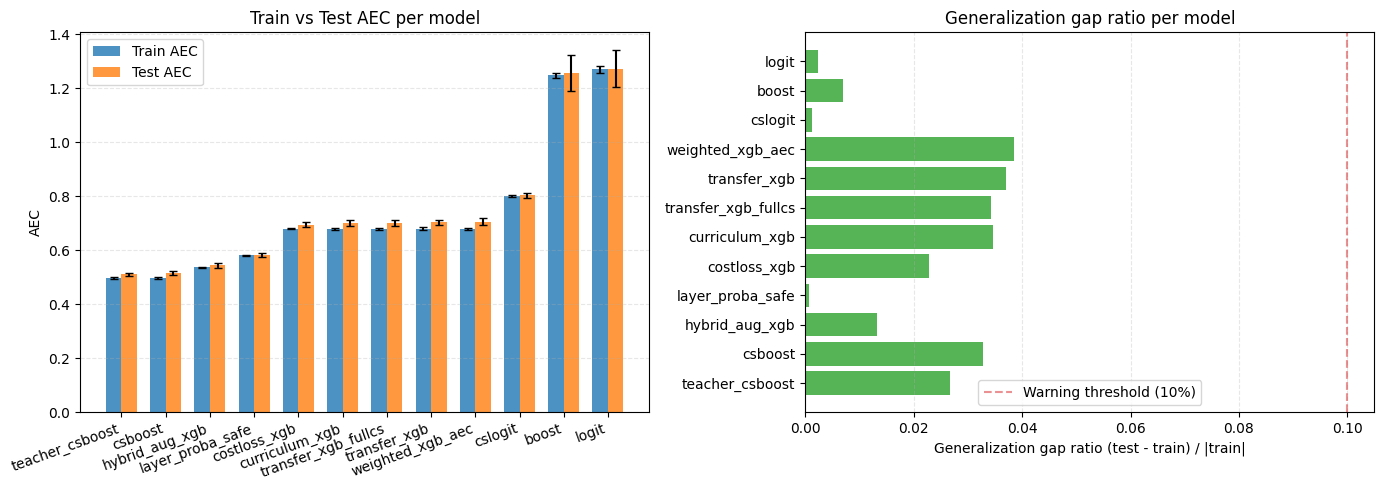

All models have acceptable generalization gap (<10%).


In [51]:
# =============================================================================
# OVERFITTING DIAGNOSTIC: TRAIN vs TEST AEC
# =============================================================================
overfit_df = fold_df.dropna(subset=['train_AEC']).copy()
overfit_summary = overfit_df.groupby('Model').agg(
    train_AEC_mean=('train_AEC', 'mean'),
    test_AEC_mean=('AEC', 'mean'),
    train_AEC_std=('train_AEC', 'std'),
    test_AEC_std=('AEC', 'std'),
).sort_values('test_AEC_mean')
overfit_summary['gap'] = overfit_summary['test_AEC_mean'] - overfit_summary['train_AEC_mean']
overfit_summary['gap_ratio'] = overfit_summary['gap'] / (overfit_summary['train_AEC_mean'].abs() + 1e-12)

print('Overfitting diagnostic (train vs test AEC):')
display(overfit_summary.round(4))

models_ordered = overfit_summary.index.tolist()
x = np.arange(len(models_ordered))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - width / 2, overfit_summary['train_AEC_mean'], width, label='Train AEC',
            yerr=overfit_summary['train_AEC_std'], capsize=3, color='tab:blue', alpha=0.8)
axes[0].bar(x + width / 2, overfit_summary['test_AEC_mean'], width, label='Test AEC',
            yerr=overfit_summary['test_AEC_std'], capsize=3, color='tab:orange', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_ordered, rotation=20, ha='right')
axes[0].set_ylabel('AEC')
axes[0].set_title('Train vs Test AEC per model')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

colors = ['tab:red' if g > 0.1 else 'tab:green' for g in overfit_summary['gap_ratio']]
axes[1].barh(models_ordered, overfit_summary['gap_ratio'], color=colors, alpha=0.8)
axes[1].set_xlabel('Generalization gap ratio (test - train) / |train|')
axes[1].set_title('Generalization gap ratio per model')
axes[1].axvline(0.1, color='tab:red', linestyle='--', alpha=0.5, label='Warning threshold (10%)')
axes[1].legend()
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

flagged = overfit_summary[overfit_summary['gap_ratio'] > 0.1]
if len(flagged):
    print(f'WARNING: {len(flagged)} model(s) have >10% generalization gap:')
    for name, row in flagged.iterrows():
        print(f'  {name}: gap_ratio={row["gap_ratio"]:.2%}')
else:
    print('All models have acceptable generalization gap (<10%).')

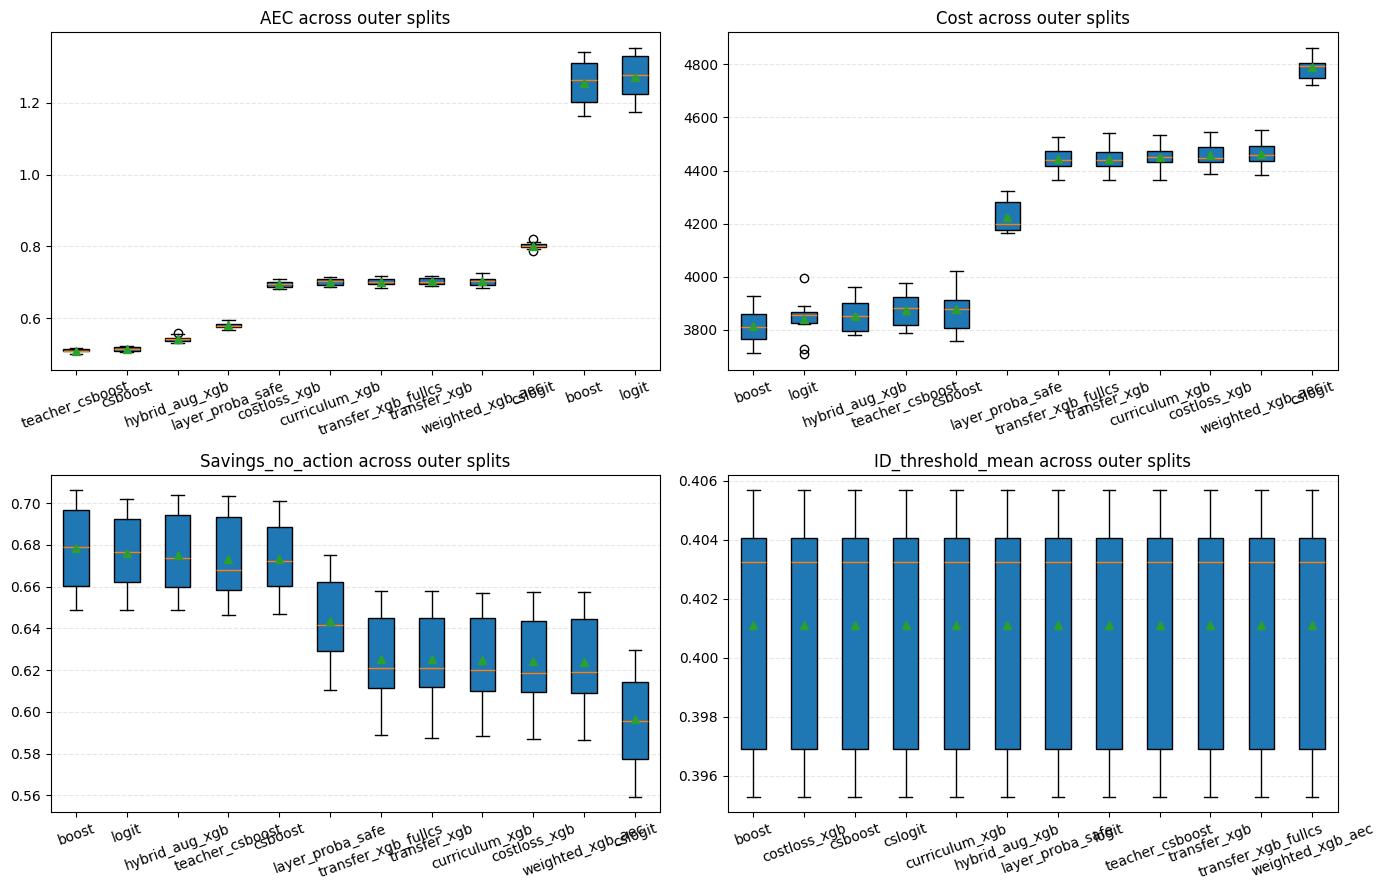

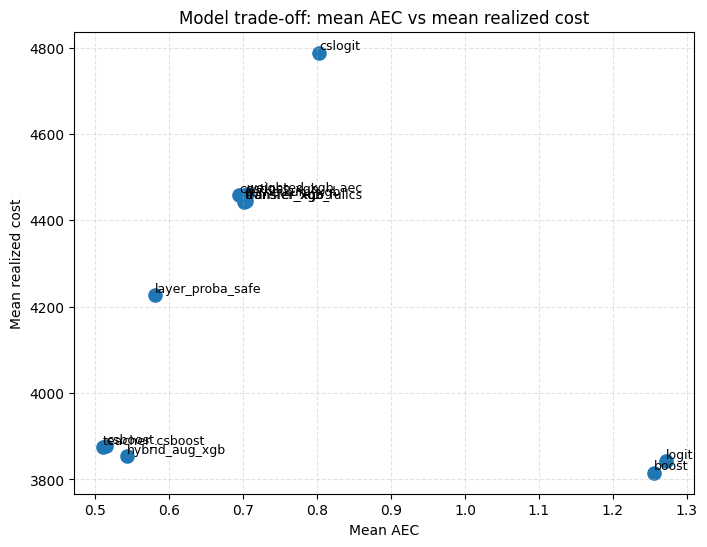

In [52]:
# =============================================================================
# PERFORMANCE VISUALIZATIONS
# =============================================================================
plot_metrics = ['AEC', 'Cost', 'Savings_no_action', 'ID_threshold_mean']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, metric in zip(axes, plot_metrics):
    order = fold_df.groupby('Model')[metric].mean().sort_values(ascending=(metric not in ['Savings_no_action'])).index.tolist()
    series_list = [fold_df.loc[fold_df['Model'] == model, metric].values for model in order]
    ax.boxplot(series_list, labels=order, patch_artist=True, showmeans=True)
    ax.set_title(f'{metric} across outer splits')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


summary_plot = pd.DataFrame(ALL_RESULTS).T.reset_index().rename(columns={'index': 'Model'})
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(summary_plot['AEC_mean'], summary_plot['Cost_mean'], s=90, color='tab:blue')
for _, row in summary_plot.iterrows():
    ax.text(row['AEC_mean'], row['Cost_mean'], str(row['Model']), fontsize=9, ha='left', va='bottom')
ax.set_xlabel('Mean AEC')
ax.set_ylabel('Mean realized cost')
ax.set_title('Model trade-off: mean AEC vs mean realized cost')
ax.grid(True, linestyle='--', alpha=0.35)
plt.show()


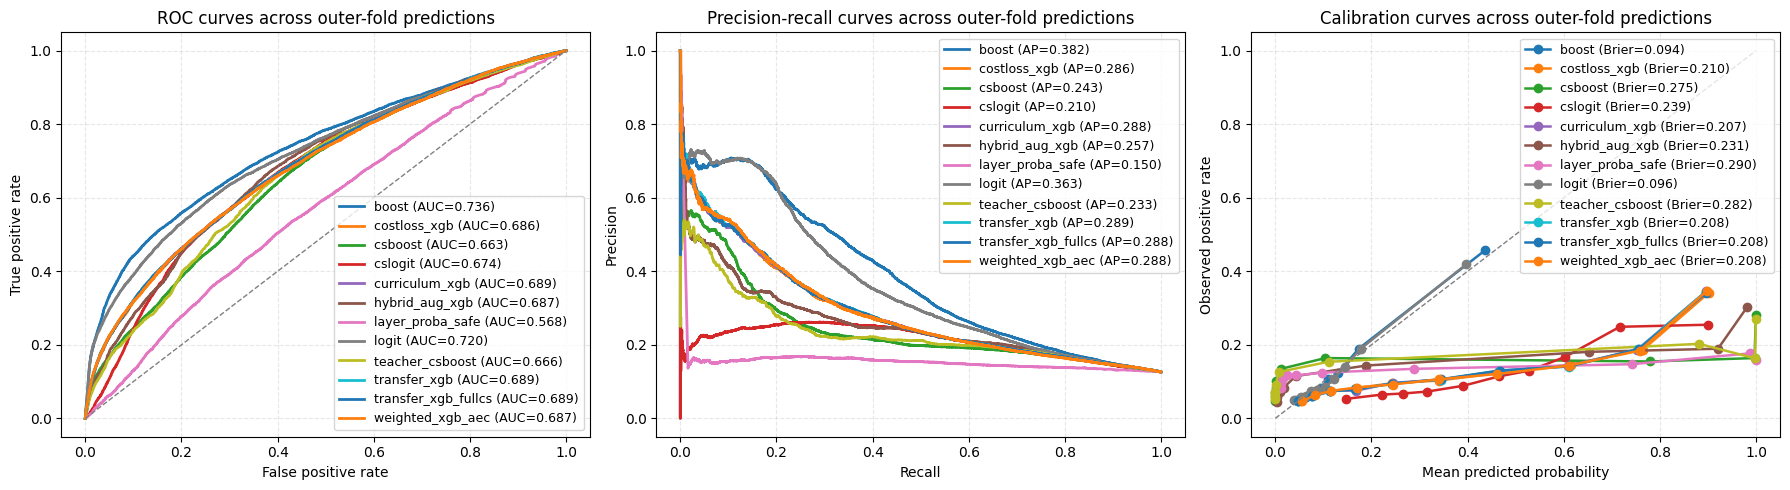

In [53]:
# =============================================================================
# PROBABILITY-QUALITY VISUALIZATIONS
# =============================================================================
prediction_df = pd.DataFrame(PREDICTION_ROWS)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model_name, model_df in prediction_df.groupby('Model'):
    fpr, tpr, _ = roc_curve(model_df['y_true'], model_df['y_prob'])
    roc_auc = roc_auc_score(model_df['y_true'], model_df['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC curves across outer-fold predictions')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].legend(fontsize=9)

for model_name, model_df in prediction_df.groupby('Model'):
    precision, recall, _ = precision_recall_curve(model_df['y_true'], model_df['y_prob'])
    ap = average_precision_score(model_df['y_true'], model_df['y_prob'])
    axes[1].plot(recall, precision, linewidth=2, label=f'{model_name} (AP={ap:.3f})')

axes[1].set_title('Precision-recall curves across outer-fold predictions')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(fontsize=9)

for model_name, model_df in prediction_df.groupby('Model'):
    frac_pos, mean_pred = calibration_curve(model_df['y_true'], model_df['y_prob'], n_bins=10, strategy='quantile')
    brier = brier_score_loss(model_df['y_true'], model_df['y_prob'])
    axes[2].plot(mean_pred, frac_pos, marker='o', linewidth=1.8, label=f'{model_name} (Brier={brier:.3f})')

axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[2].set_title('Calibration curves across outer-fold predictions')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Observed positive rate')
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


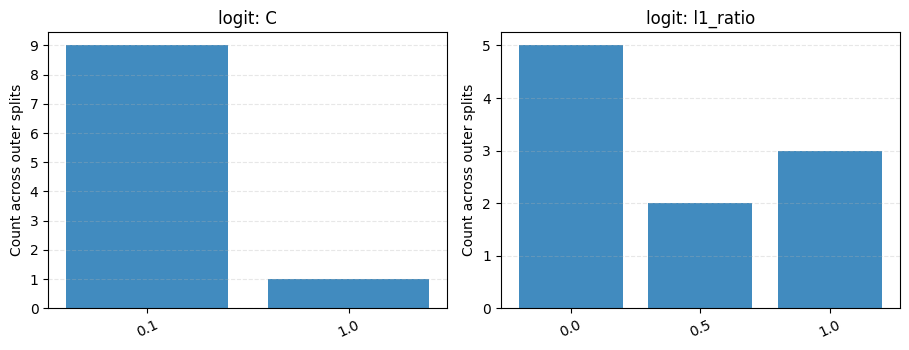

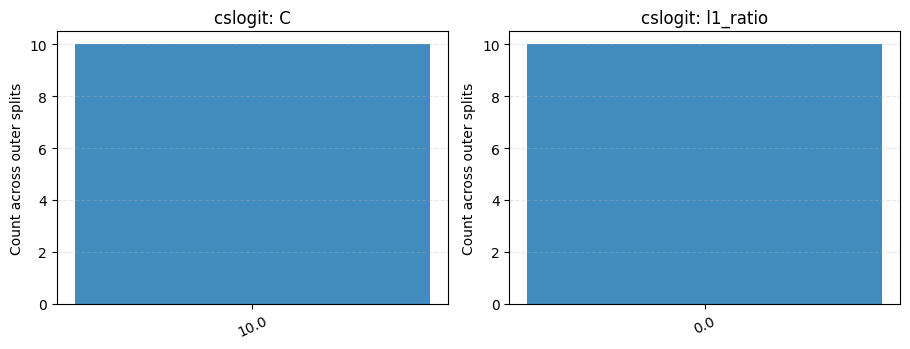

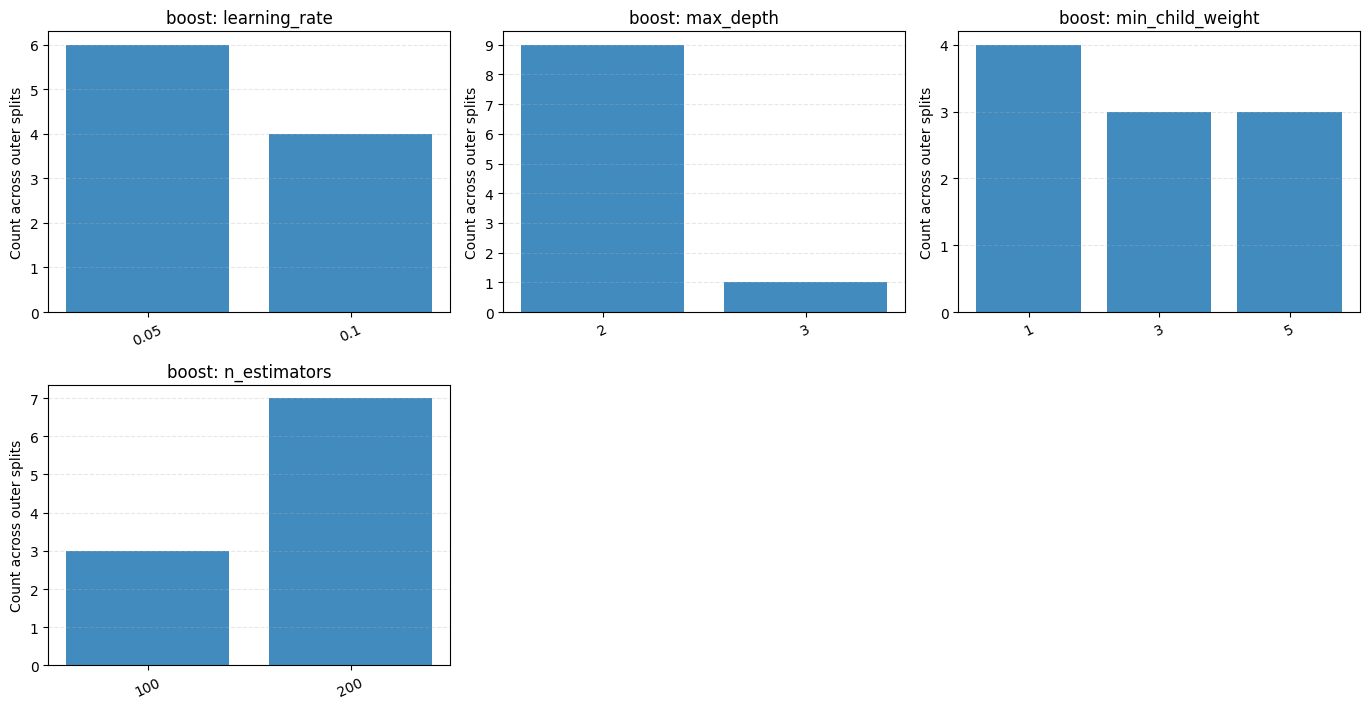

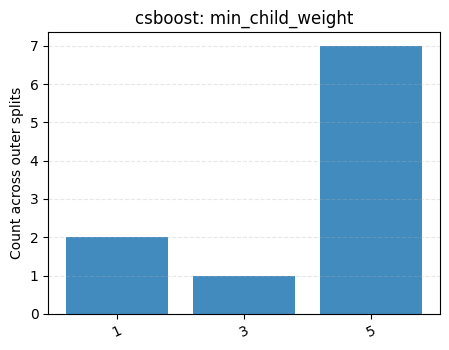

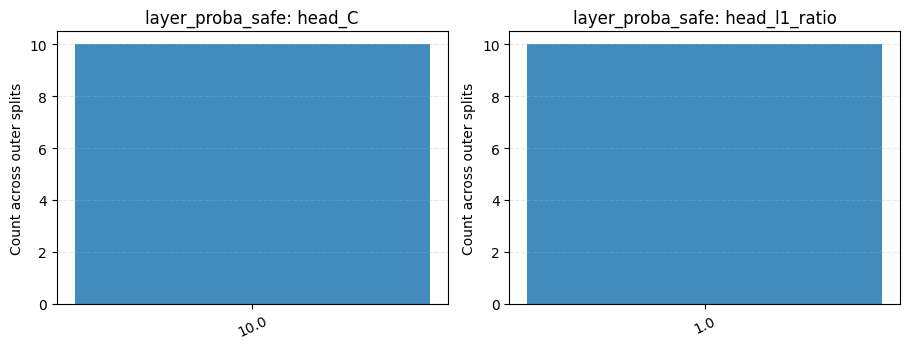

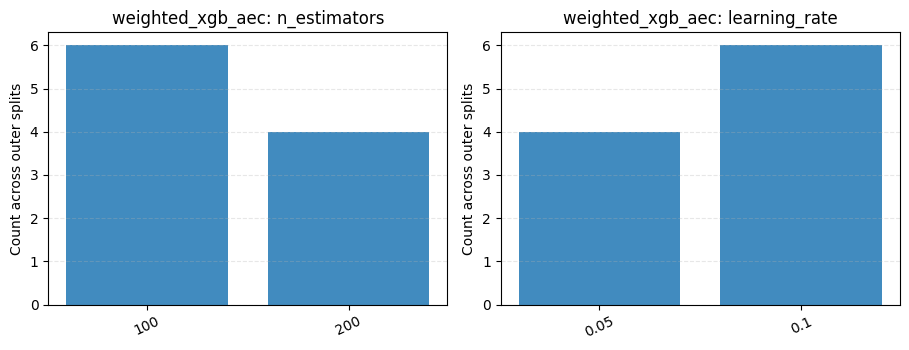

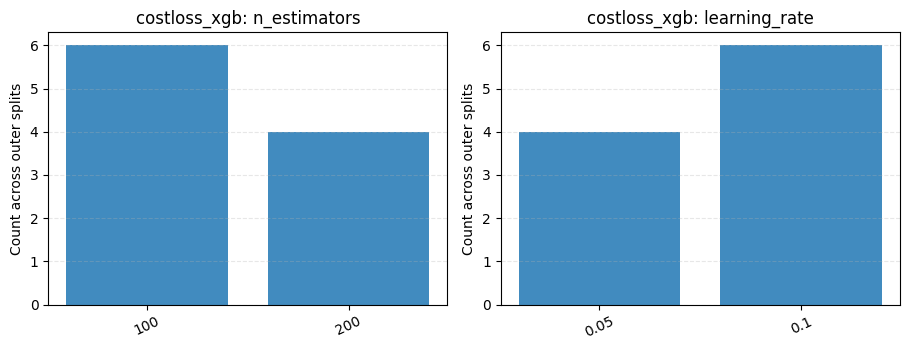

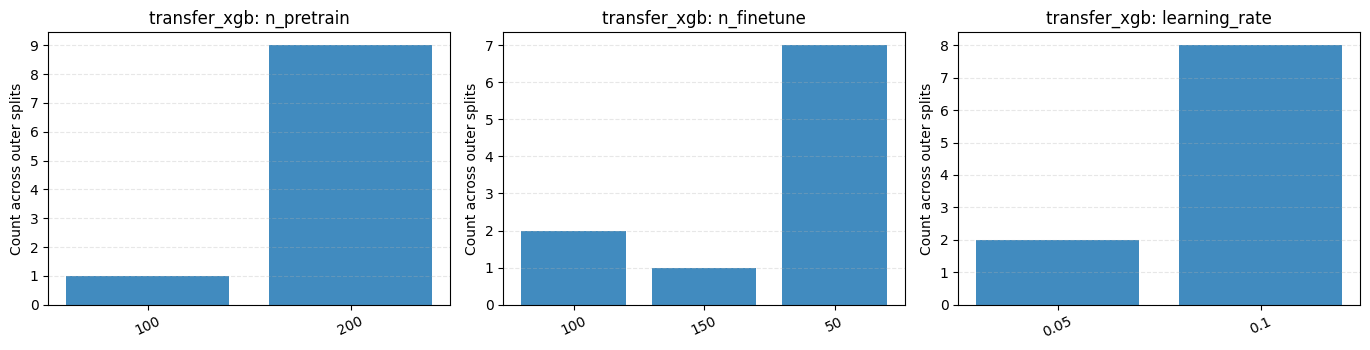

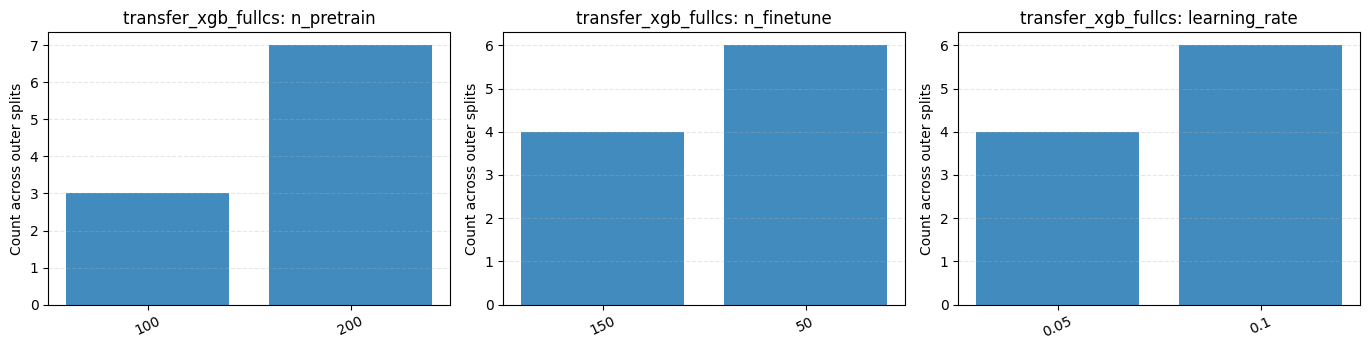

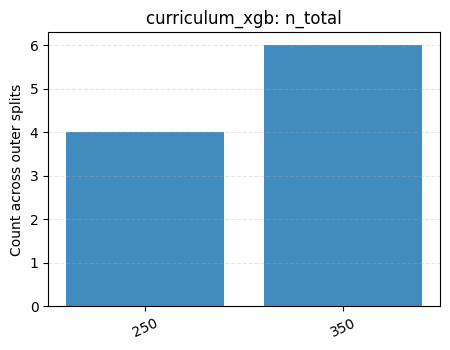

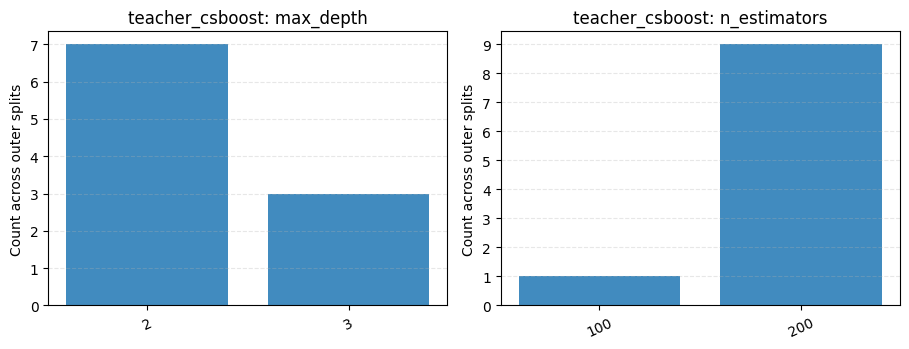

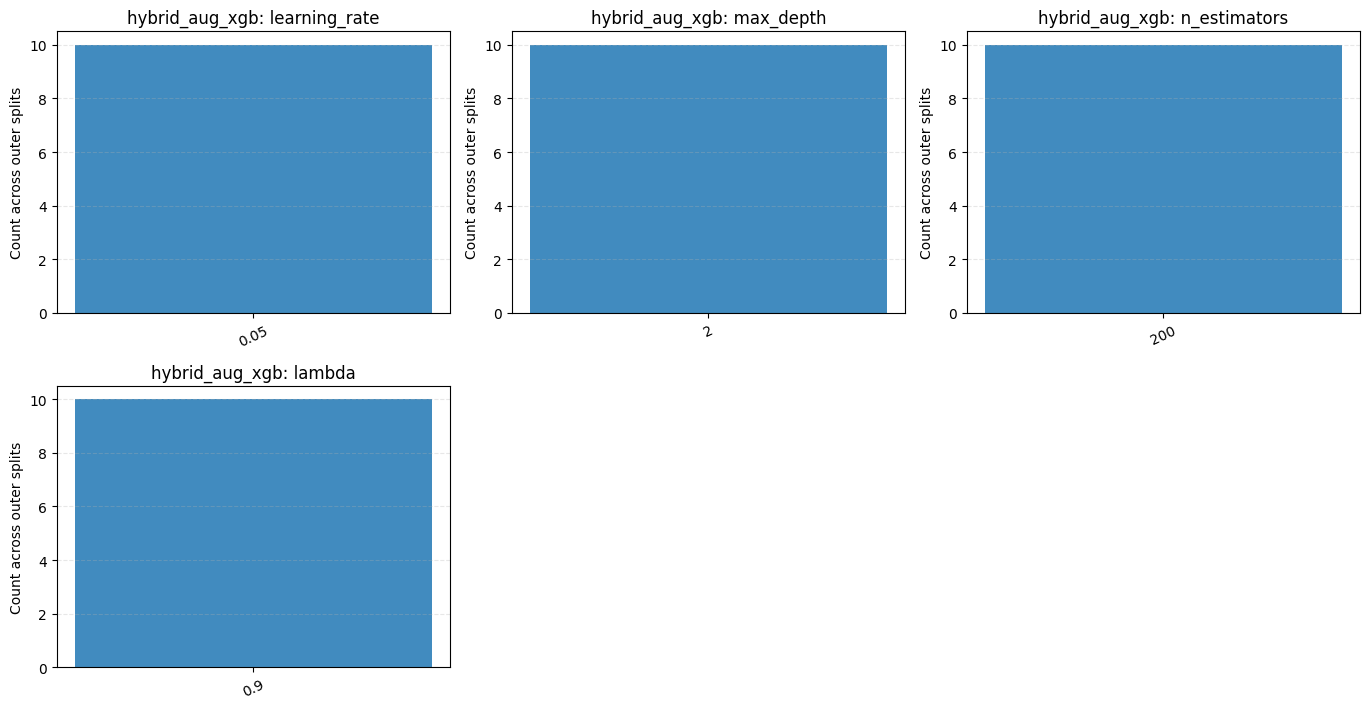

In [54]:
# =============================================================================
# HYPERPARAMETER SELECTION VISUALIZATIONS
# =============================================================================
def get_hyperparameter_columns(model_name):
    df = pd.DataFrame(FOLD_RESULTS[model_name])
    param_cols = [c for c in df.columns if c.startswith('selected_')]
    return df, param_cols


for model_name in ALL_RESULTS.keys():
    df, param_cols = get_hyperparameter_columns(model_name)
    if not param_cols:
        continue

    non_constant_cols = [col for col in param_cols if df[col].nunique(dropna=False) > 1]
    cols_to_plot = non_constant_cols if non_constant_cols else param_cols

    n_plots = len(cols_to_plot)
    n_cols = min(3, n_plots)
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.6 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, cols_to_plot):
        counts = df[col].astype(str).value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='tab:blue', alpha=0.85)
        ax.set_title(f'{model_name}: {col.replace("selected_", "")}')
        ax.set_ylabel('Count across outer splits')
        ax.tick_params(axis='x', rotation=25)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


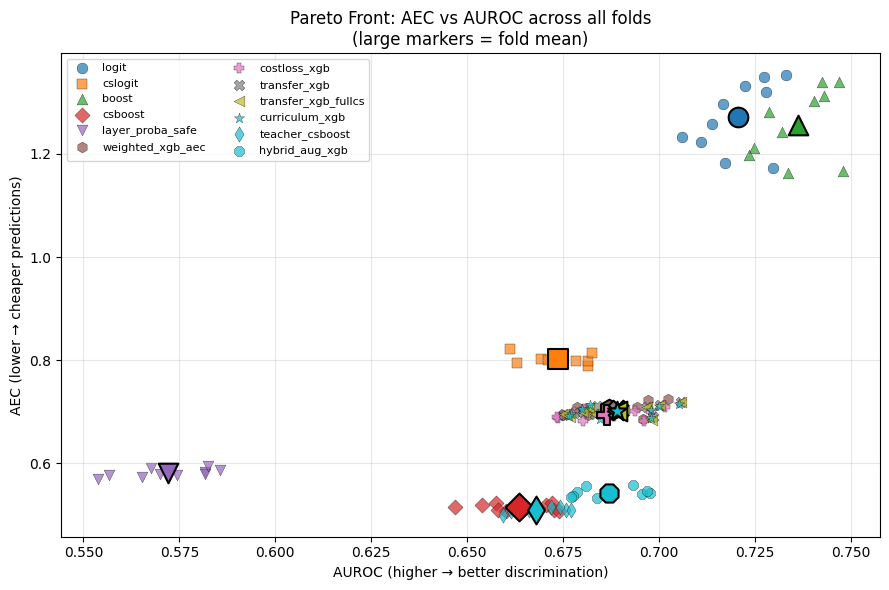

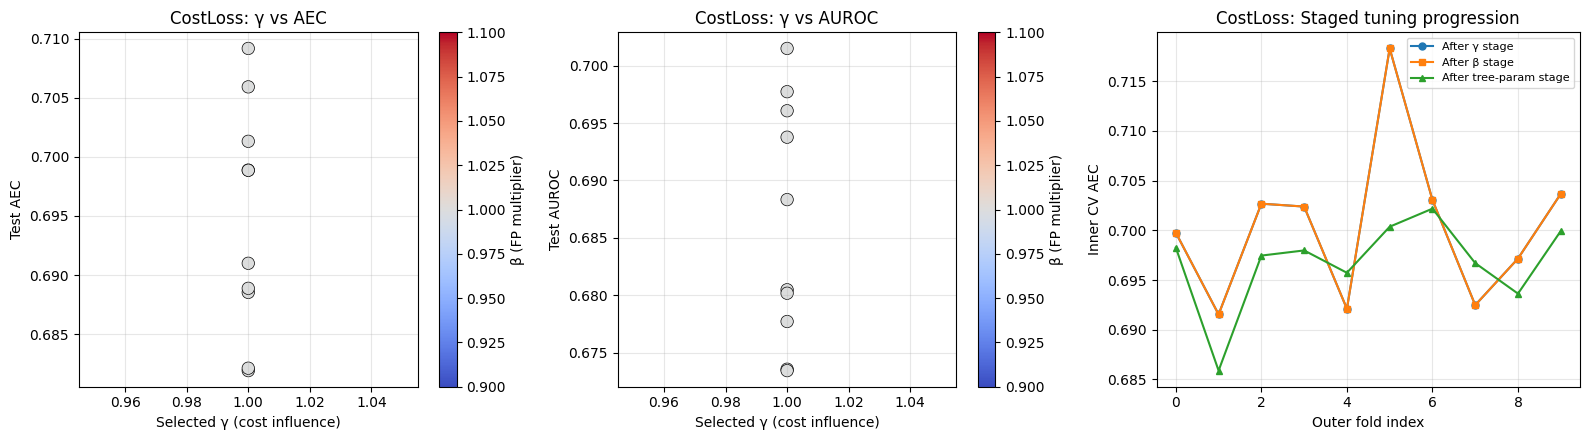

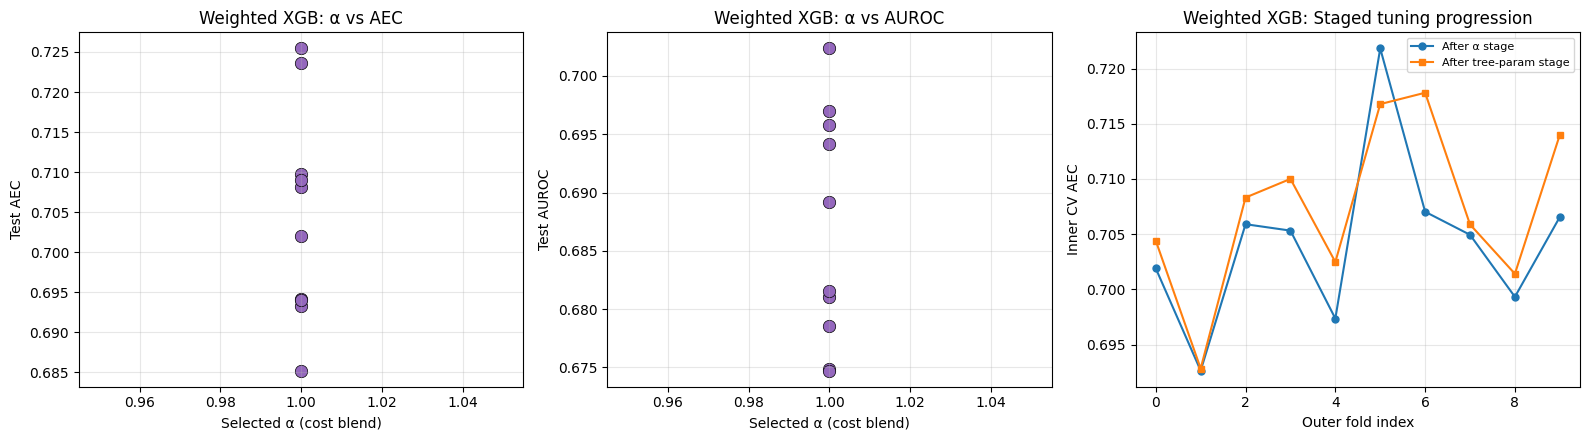

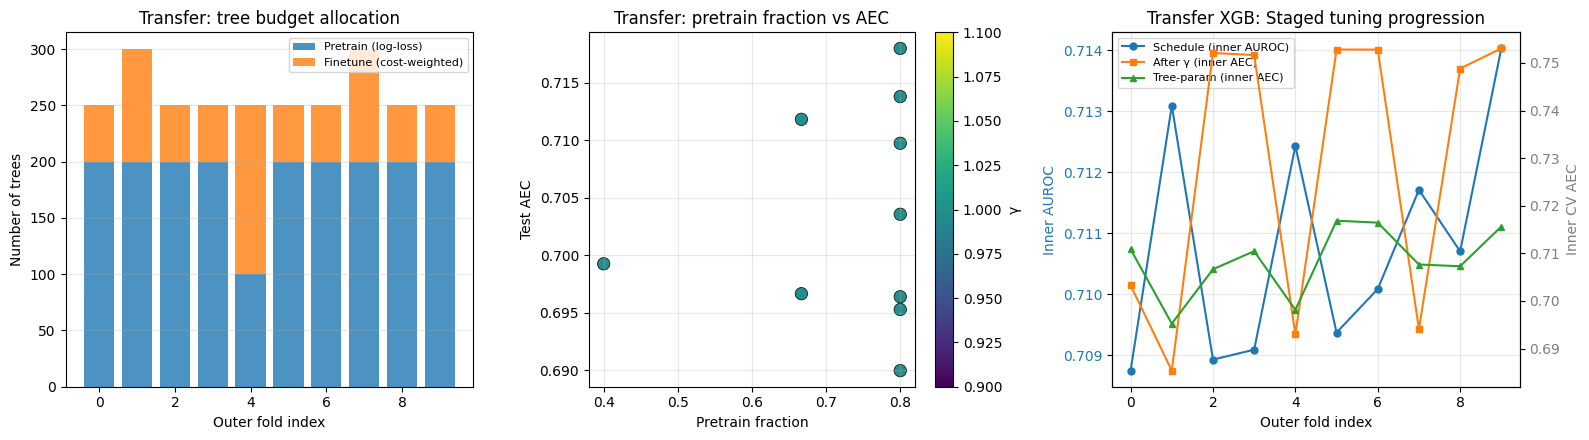

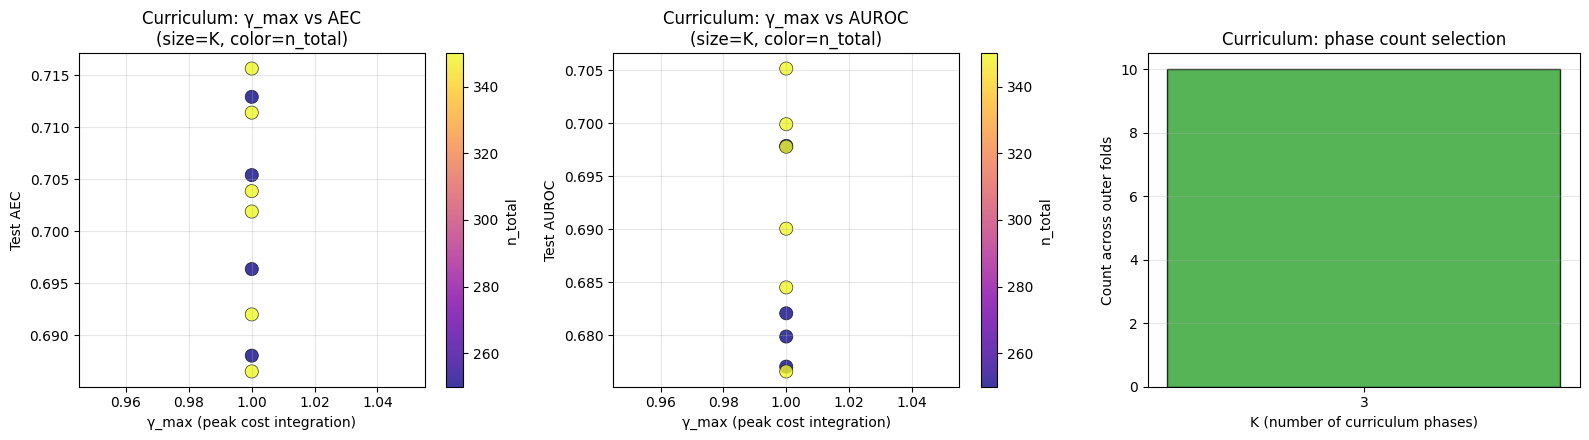

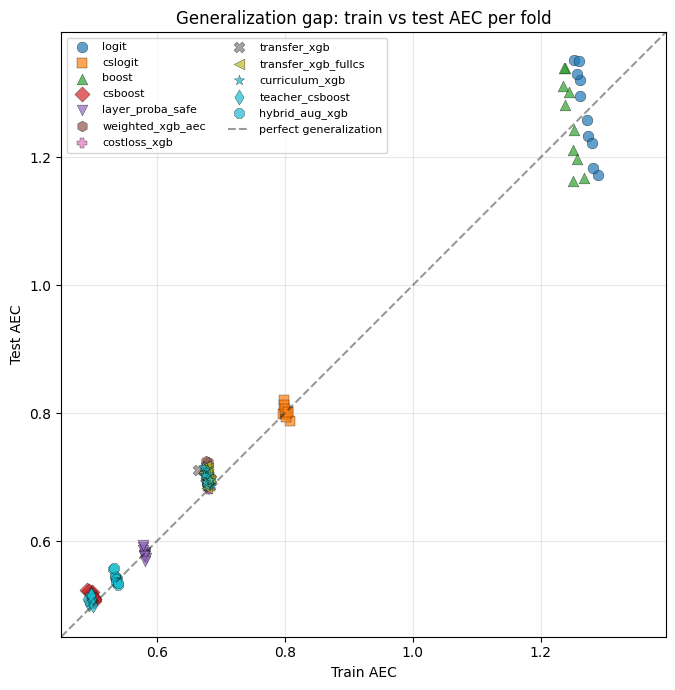

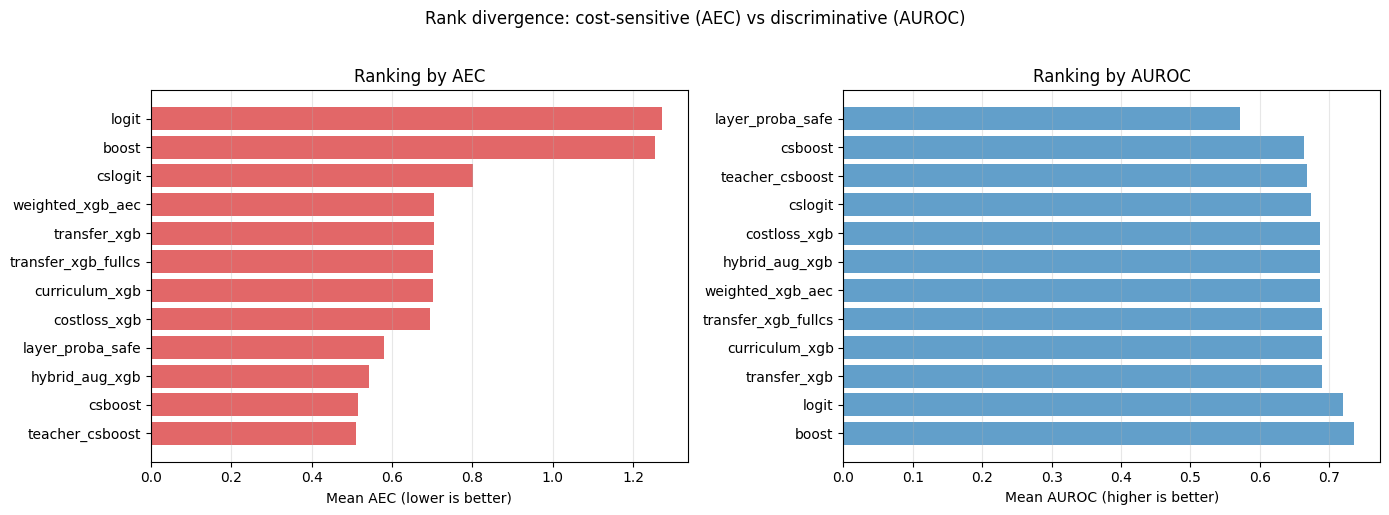

In [55]:
# =============================================================================
# MODEL-SPECIFIC DIAGNOSTIC PLOTS
# =============================================================================

# ── 1. Cross-model Pareto front: AEC vs AUROC ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
model_markers = {'logit': 'o', 'cslogit': 's', 'boost': '^', 'csboost': 'D',
                 'weighted_xgb_aec': 'h', 'costloss_xgb': 'P', 'transfer_xgb': 'X', 'transfer_xgb_fullcs': '<', 'transfer_nn': '>',
                 'curriculum_xgb': '*', 'layer_proba_safe': 'v', 'teacher_csboost': 'd',
                 'hybrid_aug_xgb': '8', 'hybrid_aug_mlp': '+'}
cmap = plt.cm.tab10
for idx, (model_name, fold_list) in enumerate(FOLD_RESULTS.items()):
    df_m = pd.DataFrame(fold_list)
    ax.scatter(df_m['AUROC'], df_m['AEC'],
               label=model_name, marker=model_markers.get(model_name, 'o'),
               color=cmap(idx), s=60, alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.scatter(df_m['AUROC'].mean(), df_m['AEC'].mean(),
               marker=model_markers.get(model_name, 'o'),
               color=cmap(idx), s=200, edgecolors='k', linewidths=1.5, zorder=5)

ax.set_xlabel('AUROC (higher → better discrimination)')
ax.set_ylabel('AEC (lower → cheaper predictions)')
ax.set_title('Pareto Front: AEC vs AUROC across all folds\n(large markers = fold mean)')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── 2. CostLoss XGB: gamma/beta sensitivity ─────────────────────────────────
if 'costloss_xgb' in FOLD_RESULTS:
    cl_df = pd.DataFrame(FOLD_RESULTS['costloss_xgb'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 2a. Gamma vs test AEC (colored by beta)
    sc = axes[0].scatter(cl_df['selected_gamma'], cl_df['AEC'],
                         c=cl_df['selected_beta'], cmap='coolwarm',
                         s=80, edgecolors='k', linewidths=0.5)
    axes[0].set_xlabel('Selected γ (cost influence)')
    axes[0].set_ylabel('Test AEC')
    axes[0].set_title('CostLoss: γ vs AEC')
    plt.colorbar(sc, ax=axes[0], label='β (FP multiplier)')
    axes[0].grid(True, alpha=0.3)

    # 2b. Gamma vs test AUROC (colored by beta)
    sc = axes[1].scatter(cl_df['selected_gamma'], cl_df['AUROC'],
                         c=cl_df['selected_beta'], cmap='coolwarm',
                         s=80, edgecolors='k', linewidths=0.5)
    axes[1].set_xlabel('Selected γ (cost influence)')
    axes[1].set_ylabel('Test AUROC')
    axes[1].set_title('CostLoss: γ vs AUROC')
    plt.colorbar(sc, ax=axes[1], label='β (FP multiplier)')
    axes[1].grid(True, alpha=0.3)

    # 2c. Inner AEC progression across tuning stages
    axes[2].plot(range(len(cl_df)), cl_df['gamma_inner_AEC'], 'o-', label='After γ stage', markersize=5)
    axes[2].plot(range(len(cl_df)), cl_df['beta_inner_AEC'], 's-', label='After β stage', markersize=5)
    axes[2].plot(range(len(cl_df)), cl_df['param_inner_AEC'], '^-', label='After tree-param stage', markersize=5)
    axes[2].set_xlabel('Outer fold index')
    axes[2].set_ylabel('Inner CV AEC')
    axes[2].set_title('CostLoss: Staged tuning progression')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── 2b. Weighted XGB: alpha sensitivity ──────────────────────────────────────
if 'weighted_xgb_aec' in FOLD_RESULTS:
    w_df = pd.DataFrame(FOLD_RESULTS['weighted_xgb_aec'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].scatter(w_df['selected_alpha'], w_df['AEC'],
                    s=80, edgecolors='k', linewidths=0.5, color='tab:purple')
    axes[0].set_xlabel('Selected α (cost blend)')
    axes[0].set_ylabel('Test AEC')
    axes[0].set_title('Weighted XGB: α vs AEC')
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(w_df['selected_alpha'], w_df['AUROC'],
                    s=80, edgecolors='k', linewidths=0.5, color='tab:purple')
    axes[1].set_xlabel('Selected α (cost blend)')
    axes[1].set_ylabel('Test AUROC')
    axes[1].set_title('Weighted XGB: α vs AUROC')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(range(len(w_df)), w_df['alpha_inner_AEC'], 'o-', label='After α stage', markersize=5)
    axes[2].plot(range(len(w_df)), w_df['param_inner_AEC'], 's-', label='After tree-param stage', markersize=5)
    axes[2].set_xlabel('Outer fold index')
    axes[2].set_ylabel('Inner CV AEC')
    axes[2].set_title('Weighted XGB: Staged tuning progression')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



# ── 3. Transfer XGB: tree allocation & gamma ────────────────────────────────
if 'transfer_xgb' in FOLD_RESULTS:
    tr_df = pd.DataFrame(FOLD_RESULTS['transfer_xgb'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 3a. Stacked bar: pretrain vs finetune tree budget
    x_pos = np.arange(len(tr_df))
    axes[0].bar(x_pos, tr_df['selected_n_pretrain'], label='Pretrain (log-loss)',
                color='tab:blue', alpha=0.8)
    axes[0].bar(x_pos, tr_df['selected_n_finetune'],
                bottom=tr_df['selected_n_pretrain'], label='Finetune (cost-weighted)',
                color='tab:orange', alpha=0.8)
    axes[0].set_xlabel('Outer fold index')
    axes[0].set_ylabel('Number of trees')
    axes[0].set_title('Transfer: tree budget allocation')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)

    # 3b. Pretrain ratio vs test AEC
    tr_df['pretrain_ratio'] = tr_df['selected_n_pretrain'] / (
        tr_df['selected_n_pretrain'] + tr_df['selected_n_finetune'])
    sc = axes[1].scatter(tr_df['pretrain_ratio'], tr_df['AEC'],
                         c=tr_df['selected_gamma'], cmap='viridis',
                         s=80, edgecolors='k', linewidths=0.5)
    axes[1].set_xlabel('Pretrain fraction')
    axes[1].set_ylabel('Test AEC')
    axes[1].set_title('Transfer: pretrain fraction vs AEC')
    plt.colorbar(sc, ax=axes[1], label='γ')
    axes[1].grid(True, alpha=0.3)

    # 3c. Schedule stage = inner AUROC; later stages = inner AEC
    ax_t = axes[2]
    ax_tr = ax_t.twinx()
    h0 = ax_t.plot(x_pos, tr_df['schedule_inner_AUROC'], 'o-', color='tab:blue',
                   label='Schedule (inner AUROC)', markersize=5)[0]
    h1 = ax_tr.plot(x_pos, tr_df['gamma_inner_AEC'], 's-', color='tab:orange',
                    label='After γ (inner AEC)', markersize=5)[0]
    h2 = ax_tr.plot(x_pos, tr_df['tree_inner_AEC'], '^-', color='tab:green',
                    label='Tree-param (inner AEC)', markersize=5)[0]
    ax_t.set_xlabel('Outer fold index')
    ax_t.set_ylabel('Inner AUROC', color='tab:blue')
    ax_tr.set_ylabel('Inner CV AEC', color='tab:gray')
    ax_t.tick_params(axis='y', labelcolor='tab:blue')
    ax_tr.tick_params(axis='y', labelcolor='tab:gray')
    ax_t.set_title('Transfer XGB: Staged tuning progression')
    ax_t.legend([h0, h1, h2], [h.get_label() for h in (h0, h1, h2)], fontsize=8, loc='best')
    ax_t.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── 3b. Transfer NN: epoch allocation & gamma ─────────────────────────────────
if 'transfer_nn' in FOLD_RESULTS:
    trn_df = pd.DataFrame(FOLD_RESULTS['transfer_nn'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    x_pos = np.arange(len(trn_df))
    axes[0].bar(x_pos, trn_df['selected_n_pretrain'], label='Pretrain (BCE)',
                color='tab:blue', alpha=0.8)
    axes[0].bar(x_pos, trn_df['selected_n_finetune'],
                bottom=trn_df['selected_n_pretrain'], label='Finetune (cost blend)',
                color='tab:orange', alpha=0.8)
    axes[0].set_xlabel('Outer fold index')
    axes[0].set_ylabel('Epochs')
    axes[0].set_title('Transfer NN: epoch budget allocation')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y', alpha=0.3)

    denom = trn_df['selected_n_pretrain'] + trn_df['selected_n_finetune'] + 1e-9
    trn_df['pretrain_ratio'] = trn_df['selected_n_pretrain'] / denom
    sc = axes[1].scatter(trn_df['pretrain_ratio'], trn_df['AEC'],
                         c=trn_df['selected_gamma'], cmap='viridis',
                         s=80, edgecolors='k', linewidths=0.5)
    axes[1].set_xlabel('Pretrain fraction')
    axes[1].set_ylabel('Test AEC')
    axes[1].set_title('Transfer NN: pretrain fraction vs AEC')
    plt.colorbar(sc, ax=axes[1], label='γ')
    axes[1].grid(True, alpha=0.3)

    ax_t = axes[2]
    ax_tr = ax_t.twinx()
    h0 = ax_t.plot(x_pos, trn_df['schedule_inner_AUROC'], 'o-', color='tab:blue',
                   label='Schedule (inner AUROC)', markersize=5)[0]
    h1 = ax_tr.plot(x_pos, trn_df['gamma_inner_AEC'], 's-', color='tab:orange',
                    label='After γ (inner AEC)', markersize=5)[0]
    h2 = ax_tr.plot(x_pos, trn_df['nn_inner_AEC'], '^-', color='tab:green',
                    label='NN-param (inner AEC)', markersize=5)[0]
    ax_t.set_xlabel('Outer fold index')
    ax_t.set_ylabel('Inner AUROC', color='tab:blue')
    ax_tr.set_ylabel('Inner CV AEC', color='tab:gray')
    ax_t.tick_params(axis='y', labelcolor='tab:blue')
    ax_tr.tick_params(axis='y', labelcolor='tab:gray')
    ax_t.set_title('Transfer NN: Staged tuning progression')
    ax_t.legend([h0, h1, h2], [h.get_label() for h in (h0, h1, h2)], fontsize=8, loc='best')
    ax_t.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── 4. Curriculum XGB: configuration impact ──────────────────────────────────

if 'curriculum_xgb' in FOLD_RESULTS:
    cu_df = pd.DataFrame(FOLD_RESULTS['curriculum_xgb'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 4a. gamma_max vs test AEC (sized by K)
    sc = axes[0].scatter(cu_df['selected_gamma_max'], cu_df['AEC'],
                         s=cu_df['selected_K'] * 30, c=cu_df['selected_n_total'],
                         cmap='plasma', edgecolors='k', linewidths=0.5, alpha=0.8)
    axes[0].set_xlabel('γ_max (peak cost integration)')
    axes[0].set_ylabel('Test AEC')
    axes[0].set_title('Curriculum: γ_max vs AEC\n(size=K, color=n_total)')
    plt.colorbar(sc, ax=axes[0], label='n_total')
    axes[0].grid(True, alpha=0.3)

    # 4b. gamma_max vs AUROC
    sc = axes[1].scatter(cu_df['selected_gamma_max'], cu_df['AUROC'],
                         s=cu_df['selected_K'] * 30, c=cu_df['selected_n_total'],
                         cmap='plasma', edgecolors='k', linewidths=0.5, alpha=0.8)
    axes[1].set_xlabel('γ_max (peak cost integration)')
    axes[1].set_ylabel('Test AUROC')
    axes[1].set_title('Curriculum: γ_max vs AUROC\n(size=K, color=n_total)')
    plt.colorbar(sc, ax=axes[1], label='n_total')
    axes[1].grid(True, alpha=0.3)

    # 4c. Number of phases distribution
    k_counts = cu_df['selected_K'].value_counts().sort_index()
    axes[2].bar(k_counts.index.astype(str), k_counts.values,
                color='tab:green', alpha=0.8, edgecolor='k')
    axes[2].set_xlabel('K (number of curriculum phases)')
    axes[2].set_ylabel('Count across outer folds')
    axes[2].set_title('Curriculum: phase count selection')
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── 5. Generalization gap scatter (train AEC vs test AEC) ───────────────────
fig, ax = plt.subplots(figsize=(8, 7))
for idx, (model_name, fold_list) in enumerate(FOLD_RESULTS.items()):
    df_m = pd.DataFrame(fold_list)
    if 'train_AEC' not in df_m.columns:
        continue
    ax.scatter(df_m['train_AEC'], df_m['AEC'],
               label=model_name, marker=model_markers.get(model_name, 'o'),
               color=cmap(idx), s=60, alpha=0.7, edgecolors='k', linewidths=0.3)

lims = ax.get_xlim() + ax.get_ylim()
lo, hi = min(lims), max(lims)
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='perfect generalization')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('Train AEC')
ax.set_ylabel('Test AEC')
ax.set_title('Generalization gap: train vs test AEC per fold')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ── 6. Cost-sensitive vs cost-insensitive metric divergence ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = list(FOLD_RESULTS.keys())
aec_means = [pd.DataFrame(FOLD_RESULTS[m])['AEC'].mean() for m in model_names]
auroc_means = [pd.DataFrame(FOLD_RESULTS[m])['AUROC'].mean() for m in model_names]

aec_rank = np.argsort(aec_means)
auroc_rank = np.argsort(auroc_means)[::-1]

y_pos = np.arange(len(model_names))
axes[0].barh(y_pos, [aec_means[i] for i in aec_rank], color='tab:red', alpha=0.7)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([model_names[i] for i in aec_rank])
axes[0].set_xlabel('Mean AEC (lower is better)')
axes[0].set_title('Ranking by AEC')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(y_pos, [auroc_means[i] for i in auroc_rank], color='tab:blue', alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([model_names[i] for i in auroc_rank])
axes[1].set_xlabel('Mean AUROC (higher is better)')
axes[1].set_title('Ranking by AUROC')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Rank divergence: cost-sensitive (AEC) vs discriminative (AUROC)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


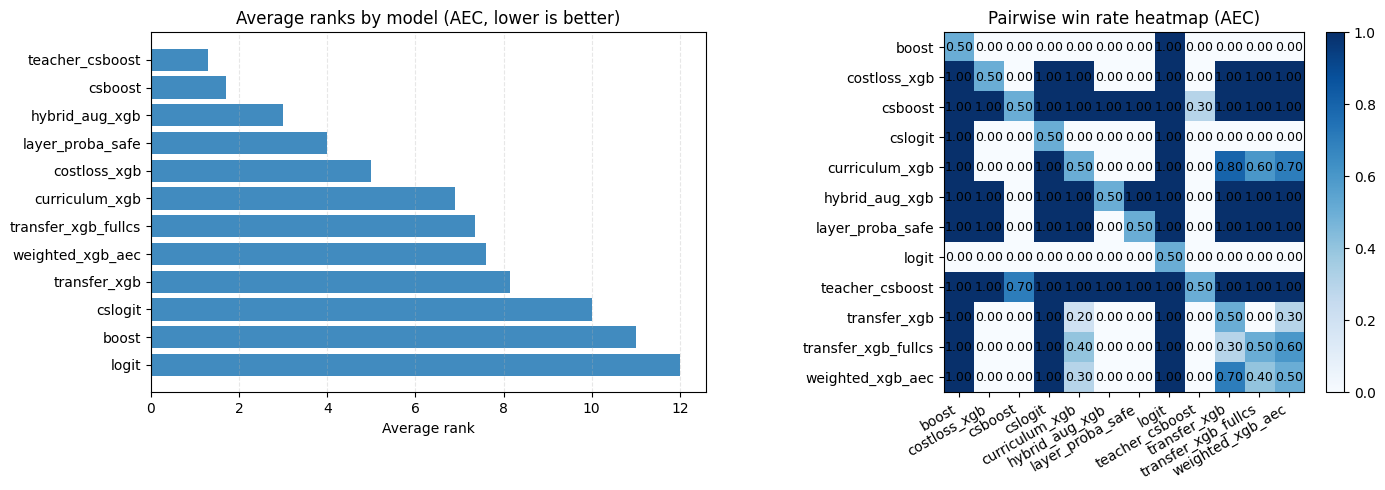

In [56]:
# =============================================================================
# RANK AND PAIRWISE WIN VISUALIZATIONS
# =============================================================================
PRIMARY_VIS_METRIC = 'AEC'
metric_pivot = fold_df.pivot(index='SplitID', columns='Model', values=PRIMARY_VIS_METRIC).sort_index(axis=1)
rank_table = metric_pivot.rank(axis=1, method='average', ascending=True)
avg_ranks = rank_table.mean(axis=0).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(avg_ranks.index, avg_ranks.values, color='tab:blue', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel('Average rank')
axes[0].set_title(f'Average ranks by model ({PRIMARY_VIS_METRIC}, lower is better)')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

models = list(metric_pivot.columns)
win_rate = pd.DataFrame(index=models, columns=models, dtype=float)
for row_model in models:
    for col_model in models:
        if row_model == col_model:
            win_rate.loc[row_model, col_model] = 0.5
        else:
            paired = metric_pivot[[row_model, col_model]].dropna()
            win_rate.loc[row_model, col_model] = float(np.mean(paired[row_model].values < paired[col_model].values))

im = axes[1].imshow(win_rate.values, cmap='Blues', vmin=0.0, vmax=1.0)
axes[1].set_xticks(range(len(models)))
axes[1].set_yticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[1].set_yticklabels(models)
axes[1].set_title(f'Pairwise win rate heatmap ({PRIMARY_VIS_METRIC})')

for i in range(len(models)):
    for j in range(len(models)):
        axes[1].text(j, i, f'{win_rate.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Friedman test for AEC:
  models: ['teacher_csboost', 'csboost', 'hybrid_aug_xgb', 'layer_proba_safe', 'costloss_xgb', 'curriculum_xgb', 'transfer_xgb_fullcs', 'weighted_xgb_aec', 'transfer_xgb', 'cslogit', 'boost', 'logit']
  statistic = 106.7189
  p-value   = 0.000000
  Average ranks (lower is better):


,average_rank
Model,
teacher_csboost,1.30
csboost,1.70
hybrid_aug_xgb,3.00
layer_proba_safe,4.00
costloss_xgb,5.00
curriculum_xgb,6.90
transfer_xgb_fullcs,7.35
weighted_xgb_aec,7.60
transfer_xgb,8.15


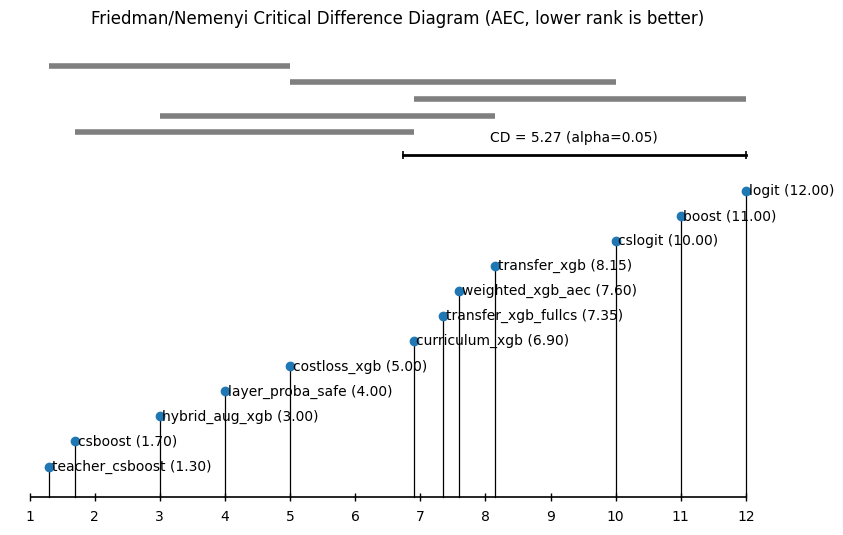

In [57]:
# =============================================================================
# FRIEDMAN TEST + NEMENYI CRITICAL DIFFERENCE DIAGRAM
# =============================================================================
PRIMARY_METRIC = 'AEC'
ALPHA = 0.05


def friedman_rank_table(df, metric):
    pivot = df.pivot(index='SplitID', columns='Model', values=metric).sort_index(axis=1)
    ranks = pivot.rank(axis=1, method='average', ascending=True)
    avg_ranks = ranks.mean(axis=0).sort_values()
    stat, p_value = scipy_stats.friedmanchisquare(*[pivot[col].values for col in pivot.columns])
    return pivot, ranks, avg_ranks, float(stat), float(p_value)


def nemenyi_cd(n_models, n_splits, alpha=0.05):
    q_alpha = scipy_stats.studentized_range.ppf(1 - alpha, n_models, np.inf) / np.sqrt(2)
    return float(q_alpha * np.sqrt(n_models * (n_models + 1) / (6.0 * n_splits)))


def maximal_nonsignificant_cliques(avg_ranks, cd):
    from itertools import combinations

    model_names = list(avg_ranks.index)
    rank_map = avg_ranks.to_dict()
    all_groups = []

    for r in range(2, len(model_names) + 1):
        for subset in combinations(model_names, r):
            if all(abs(rank_map[a] - rank_map[b]) <= cd + 1e-12 for i, a in enumerate(subset) for b in subset[i + 1:]):
                all_groups.append(subset)

    maximal_groups = []
    for group in all_groups:
        if not any(set(group) < set(other) for other in all_groups):
            maximal_groups.append(group)

    deduped = []
    seen = set()
    for group in maximal_groups:
        if group not in seen:
            deduped.append(group)
            seen.add(group)

    deduped.sort(
        key=lambda group: (
            -(max(rank_map[m] for m in group) - min(rank_map[m] for m in group)),
            -len(group),
            tuple(group),
        )
    )
    return deduped


def plot_cd_diagram(avg_ranks, cd, metric='AEC', alpha=0.05):
    avg_ranks = avg_ranks.sort_values()
    models = list(avg_ranks.index)
    ranks = avg_ranks.values
    n_models = len(models)

    fig_height = 2.2 + 0.35 * n_models
    fig, ax = plt.subplots(figsize=(10, fig_height))

    x_min, x_max = 1, n_models
    axis_y = 0.2
    ax.hlines(axis_y, x_min, x_max, color='black', linewidth=1.2)
    for tick in range(1, n_models + 1):
        ax.vlines(tick, axis_y - 0.03, axis_y + 0.03, color='black', linewidth=1.0)
        ax.text(tick, axis_y - 0.09, f'{tick}', ha='center', va='top', fontsize=10)

    for idx, (model, rank) in enumerate(zip(models, ranks)):
        y = 0.42 + idx * 0.18
        ax.plot([rank, rank], [axis_y, y], color='black', linewidth=0.9)
        ax.scatter(rank, y, s=36, color='tab:blue', zorder=3)
        ax.text(rank + 0.04, y, f'{model} ({rank:.2f})', va='center', ha='left', fontsize=10)

    cd_y = 0.42 + n_models * 0.18 + 0.08
    ax.plot([x_max - cd, x_max], [cd_y, cd_y], color='black', linewidth=2.0)
    ax.vlines([x_max - cd, x_max], cd_y - 0.03, cd_y + 0.03, color='black', linewidth=1.2)
    ax.text(x_max - cd / 2, cd_y + 0.07, f'CD = {cd:.2f} (alpha={alpha:.2f})', ha='center', va='bottom', fontsize=10)

    line_y = cd_y + 0.16
    used_spans = set()
    for clique in maximal_nonsignificant_cliques(avg_ranks, cd):
        clique_ranks = [avg_ranks[m] for m in clique]
        span = (round(min(clique_ranks), 6), round(max(clique_ranks), 6))
        if span in used_spans:
            continue
        used_spans.add(span)
        ax.hlines(line_y, min(clique_ranks), max(clique_ranks), color='tab:gray', linewidth=4)
        line_y += 0.12

    ax.set_xlim(0.7, n_models + 0.6)
    ax.set_ylim(0.0, line_y + 0.12)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'Friedman/Nemenyi Critical Difference Diagram ({metric}, lower rank is better)')
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_visible(False)
    plt.show()


pivot, rank_table, avg_ranks, friedman_stat, friedman_p = friedman_rank_table(fold_df, PRIMARY_METRIC)
cd = nemenyi_cd(n_models=len(avg_ranks), n_splits=len(pivot), alpha=ALPHA)

print(f'Friedman test for {PRIMARY_METRIC}:')
print(f'  models: {list(avg_ranks.index)}')
print(f'  statistic = {friedman_stat:.4f}')
print(f'  p-value   = {friedman_p:.6f}')
print('  Average ranks (lower is better):')
display(avg_ranks.rename('average_rank').to_frame())

plot_cd_diagram(avg_ranks, cd, metric=PRIMARY_METRIC, alpha=ALPHA)


In [58]:
# =============================================================================
# PAIRWISE WILCOXON TESTS VS BASELINES (with Holm-Bonferroni correction)
# =============================================================================
ALPHA_PRIMARY = 0.05
ALPHA_SECONDARY = 0.10


def holm_bonferroni(p_values):
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.ones(n, dtype=float)
    cummax = 0.0
    for rank, idx in enumerate(order):
        corrected = p_values[idx] * (n - rank)
        cummax = max(cummax, corrected)
        adjusted[idx] = min(cummax, 1.0)
    return adjusted


def significance_marker(p_value):
    if p_value < ALPHA_PRIMARY:
        return '**'
    if p_value < ALPHA_SECONDARY:
        return '*'
    return ''


def rank_biserial_correlation(x, y):
    """Matched-pairs rank-biserial correlation (effect size for Wilcoxon)."""
    diff = x - y
    diff = diff[diff != 0]
    n = len(diff)
    if n == 0:
        return 0.0
    abs_diff = np.abs(diff)
    ranks = scipy_stats.rankdata(abs_diff)
    r_plus = np.sum(ranks[diff > 0])
    r_minus = np.sum(ranks[diff < 0])
    return float((r_plus - r_minus) / (r_plus + r_minus)) if (r_plus + r_minus) > 0 else 0.0


def pairwise_wilcoxon_vs_baselines(df, target_models, baseline_models, metric):
    pivot = df.pivot(index='SplitID', columns='Model', values=metric)
    rows = []
    lower_is_better = metric in ['AEC', 'Cost', 'Brier']

    for target in target_models:
        for baseline in baseline_models:
            paired = pivot[[target, baseline]].dropna()
            x = paired[target].values
            y = paired[baseline].values
            try:
                stat, p_value = scipy_stats.wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')
                stat = float(stat)
                p_value = float(p_value)
            except ValueError:
                stat = np.nan
                p_value = 1.0

            target_mean = float(np.mean(x))
            baseline_mean = float(np.mean(y))
            mean_diff = target_mean - baseline_mean
            better_than_baseline = mean_diff < 0 if lower_is_better else mean_diff > 0
            r_rb = rank_biserial_correlation(x, y)

            rows.append({
                'metric': metric,
                'target': target,
                'baseline': baseline,
                'target_mean': target_mean,
                'baseline_mean': baseline_mean,
                'mean_diff': mean_diff,
                'wilcoxon_stat': stat,
                'p_value': p_value,
                'effect_size_r': r_rb,
                'better_than_baseline': better_than_baseline,
            })

    result_df = pd.DataFrame(rows)
    raw_p = result_df['p_value'].values
    adjusted_p = holm_bonferroni(raw_p)
    result_df['p_adjusted'] = adjusted_p
    result_df['sig_marker'] = result_df['p_adjusted'].apply(significance_marker)
    result_df['result'] = result_df.apply(
        lambda r: (f"{r['sig_marker']} better" if r['better_than_baseline'] else f"{r['sig_marker']} worse")
        if r['sig_marker'] else 'n.s.',
        axis=1,
    )
    return result_df



weighted_models = ['weighted_xgb_aec', 'layer_proba_safe', 'costloss_xgb', 'transfer_xgb', 'transfer_xgb_fullcs', 'transfer_nn', 'curriculum_xgb', 'teacher_csboost']
baseline_models = ['logit', 'cslogit', 'boost', 'csboost']

WILCOXON_METRICS = [
    'AEC', 'Cost', 'Brier', 'AUROC', 'AP', 'F1',
    'Savings_no_action', 'Savings_best_trivial', 'Spearman',
]

wilcoxon_display_cols = ['target', 'baseline', 'target_mean', 'baseline_mean',
                         'mean_diff', 'effect_size_r', 'p_value', 'p_adjusted', 'result']

all_wilcoxon = {}
for metric in WILCOXON_METRICS:
    wdf = pairwise_wilcoxon_vs_baselines(fold_df, weighted_models, baseline_models, metric)
    all_wilcoxon[metric] = wdf
    direction = '(lower is better)' if metric in ['AEC', 'Cost', 'Brier'] else '(higher is better)'
    print(f'\nWilcoxon signed-rank tests — {metric} {direction}  (Holm-Bonferroni corrected)')
    print('** p_adj < 0.05 | * p_adj < 0.10 | n.s. = not significant')
    display(wdf.sort_values(['target', 'baseline'])[wilcoxon_display_cols])


KeyError: "['transfer_nn'] not in index"